# Bangkok Traffic — Colab แบบไฟล์เดียว

เปิดไฟล์นี้ใน Google Colab แล้วเลือก **Runtime → Run all** จากนั้นอัปโหลด Excel ที่มีชีต `traffic_data` ไม่ต้องอัปโหลดโฟลเดอร์ src หรือใช้ Notebook เก่า

กติกาเดิม: ใช้ covid_period จากไฟล์; Date/month/year เป็นวันที่รายงาน; ช่องว่างและ - ของจำนวนรถเป็น 0; เก็บต้นฉบับและบันทึกค่าที่แทน วิเคราะห์เฉพาะชุดที่จับคู่ได้ ผลยังเป็นฉบับร่าง

In [1]:
from pathlib import Path
import os, sys, importlib.util, subprocess
packages = {'pandas':'pandas', 'numpy':'numpy', 'openpyxl':'openpyxl', 'matplotlib':'matplotlib', 'seaborn':'seaborn'}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
from IPython.display import display, Image, Markdown
import pandas as pd
IN_COLAB = 'google.colab' in sys.modules
if not IN_COLAB:
    try:
        import google.colab
        IN_COLAB = True
    except ImportError:
        pass
ROOT = (Path('/content') if IN_COLAB else Path.cwd()) / 'bangkok_traffic_project'
for folder in ['data/raw', 'data/interim', 'data/processed', 'outputs/current_audit', 'outputs/eda/figures']:
    (ROOT / folder).mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_rows', 12)
pd.set_option('display.max_columns', 10)

## เลือก Excel
บน Colab จะมีปุ่มอัปโหลด ถ้ารันในคอมพิวเตอร์ให้กรอก INPUT_PATH หรือกำหนด environment variable TRAFFIC_INPUT ไม่ต้องย้ายโฟลเดอร์โปรเจกต์

In [2]:
INPUT_PATH = ''  # Local example: r'C:/Downloads/traffic.xlsx'
chosen = INPUT_PATH or os.environ.get('TRAFFIC_INPUT', '')
if chosen:
    INPUT = Path(chosen).expanduser().resolve()
elif IN_COLAB:
    from google.colab import files
    uploaded = files.upload()
    excel_files = [name for name in uploaded if name.lower().endswith('.xlsx')]
    if len(excel_files) != 1:
        raise ValueError('กรุณาอัปโหลดไฟล์ .xlsx เพียงหนึ่งไฟล์ แล้วรันเซลล์นี้ใหม่')
    INPUT = Path(excel_files[0]).resolve()
else:
    raise ValueError('กรุณากรอก INPUT_PATH เป็นพาธไฟล์ Excel ในเซลล์นี้')
if not INPUT.is_file():
    raise FileNotFoundError(f'ไม่พบไฟล์ Excel: {INPUT}')
with pd.ExcelFile(INPUT) as workbook:
    if 'traffic_data' not in workbook.sheet_names:
        raise ValueError('ไฟล์นี้ไม่มีชีต traffic_data')
print('Input:', INPUT.name)

Input: bangkok_traffic_2560_Present (NotFinal) (1).xlsx


## ฟังก์ชันตรวจข้อมูลและ matching
โค้ดรวมอยู่ใน Notebook นี้แล้ว ไม่ต้อง import โมดูลของโปรเจกต์จาก src

In [3]:
"""Reproducible feasibility audit. No traffic-volume EDA or charts."""
from pathlib import Path
import argparse, datetime, hashlib, json, re, shutil, unicodedata
import numpy as np
import pandas as pd

VEHICLES = ['passenger_car','pickup_van','large_bus','small_bus','truck','tuk_tuk']
PERIODS = ['ก่อนโควิด','โควิด','หลังโควิด']
THAI_MONTHS = ['ม.ค.','ก.พ.','มี.ค.','เม.ย.','พ.ค.','มิ.ย.','ก.ค.','ส.ค.','ก.ย.','ต.ค.','พ.ย.','ธ.ค.']

def normalize(value):
    if pd.isna(value): return ''
    return re.sub(r'\s+', ' ', unicodedata.normalize('NFC',str(value))).strip()

def survey_date(value):
    if pd.isna(value): return pd.NaT
    if isinstance(value,(datetime.date,datetime.datetime,pd.Timestamp)):
        return pd.Timestamp(value).normalize()
    text=normalize(value).translate(str.maketrans('๐๑๒๓๔๕๖๗๘๙','0123456789'))
    text=re.sub(r'\s*/\s*','/',text)
    match=re.search(r'(\d{1,2})\s*([ก-๙.]+)\s*(\d{2,4})',text)
    if match:
        day,month,year=match.groups(); year=int(year)
        if year<100: year+=2500
        if year>2400: year-=543
        try: return pd.Timestamp(year=year,month=THAI_MONTHS.index(month)+1,day=int(day))
        except ValueError: return pd.NaT
    # This workbook uses explicit day/month/year text (e.g. 29/5/2026).
    if re.fullmatch(r"\d{1,2}/\d{1,2}/\d{4}",text):
        return pd.to_datetime(text,format="%d/%m/%Y",errors="coerce")
    # ISO dates remain supported.
    if re.fullmatch(r'\d{4}-\d{2}-\d{2}(?:[ T].*)?',text):
        return pd.to_datetime(text,errors='coerce')
    return pd.NaT

def time_bounds(value):
    found=re.findall(r'(\d{1,2})[.:](\d{2})',normalize(value))
    if len(found)!=2: return None,None,None
    values=[int(h)*60+int(m) for h,m in found]
    if any(int(h)>23 or int(m)>59 for h,m in found) or values[1]<=values[0]:
        return None,None,None
    return f'{values[0]//60:02d}:{values[0]%60:02d}',f'{values[1]//60:02d}:{values[1]%60:02d}',(values[1]-values[0])/60

def save_csv(frame,path): frame.to_csv(path,index=False,encoding='utf-8-sig')

def matching(frame,keys):
    usable=frame.loc[frame.covid_period.isin(PERIODS)].dropna(subset=keys)
    matrix=usable.groupby(keys+['covid_period'],dropna=False).size().unstack(fill_value=0).reindex(columns=PERIODS,fill_value=0)
    complete=matrix.loc[matrix.gt(0).all(axis=1)]
    joined=usable.merge(complete.reset_index()[keys],on=keys,how='inner',validate='many_to_one')
    return matrix,complete,joined

def run_audit(source,output=None):
    source=Path(source).resolve()
    output=Path(output or ROOT/'outputs/current_audit').resolve();output.mkdir(parents=True,exist_ok=True)
    source_hash=hashlib.sha256(source.read_bytes()).hexdigest()
    snapshots=ROOT/'data/raw';snapshots.mkdir(parents=True,exist_ok=True)
    snapshot=snapshots/f'traffic_{source_hash[:12]}.xlsx'
    if not snapshot.exists(): shutil.copyfile(source,snapshot)
    assert hashlib.sha256(snapshot.read_bytes()).hexdigest()==source_hash
    raw=pd.read_excel(snapshot,sheet_name='traffic_data')
    required=['id','survey_date','Date','month','year','covid_period','intersection','road','time_period']+VEHICLES
    missing=set(required)-set(raw.columns)
    if missing: raise ValueError(f'Missing required columns: {sorted(missing)}')
    d=raw.copy();d.insert(0,'source_excel_row',np.arange(2,len(d)+2))
    d['source_sha256']=source_hash;d['source_sheet']='traffic_data'
    d['intersection_key']=d.intersection.map(normalize);d['road_key']=d.road.map(normalize)
    # Keep the supplied covid_period, including unexpected labels for the audit.
    d['report_day']=pd.to_numeric(d.Date,errors='coerce')
    d['report_month']=pd.to_numeric(d.month,errors='coerce')
    d['report_year']=pd.to_numeric(d.year,errors='coerce')
    d['report_date']=pd.to_datetime(dict(year=d.report_year,month=d.report_month,day=d.report_day),errors='coerce')
    d['survey_date_parsed']=d.survey_date.map(survey_date)
    d['survey_month']=d.survey_date_parsed.dt.month
    d['survey_year']=d.survey_date_parsed.dt.year
    d['report_quarter']=((d.report_month-1)//3+1).where(d.report_month.between(1,12))
    bounds=d.time_period.map(time_bounds)
    d[['start_time','end_time','period_hours']]=pd.DataFrame(bounds.tolist(),index=d.index)
    d['time_key']=d.start_time.fillna('')+'-'+d.end_time.fillna('')
    changes=[];numeric_profile=[]
    for col in VEHICLES:
        text=d[col].map(normalize)
        zero=d[col].isna() | text.isin(['','-'])
        cleaned=pd.to_numeric(text.str.replace(',','',regex=False).mask(zero,'0'),errors='coerce')
        d[col+'_clean']=cleaned;d[col+'_zero_assumed']=zero
        for row in d.index[zero]: changes.append({'source_excel_row':int(d.at[row,'source_excel_row']),'field':col,'original_value':d.at[row,col],'replacement':0,'reason':'user_rule_missing_or_dash_is_zero'})
        numeric_profile.append(dict(field=col,blank=int((d[col].isna()|text.eq('')).sum()),dash=int(text.eq('-').sum()),zero_assumed=int(zero.sum()),unresolved=int(cleaned.isna().sum()),negative=int(cleaned.lt(0).sum()),fractional=int((cleaned.notna()&cleaned.mod(1).ne(0)).sum())))
    numeric=d[[c+'_clean' for c in VEHICLES]]
    d['has_assumed_zero']=d[[c+'_zero_assumed' for c in VEHICLES]].any(axis=1)
    d['numeric_unresolved']=numeric.isna().any(axis=1)
    d['numeric_negative']=numeric.lt(0).any(axis=1)
    d['numeric_fractional']=(numeric.notna()&numeric.mod(1).ne(0)).any(axis=1)
    d['exact_repeat']=raw.drop(columns='id').duplicated(keep='first')
    # Repeated survey observations can appear in different reports: audit, do not silently delete.
    survey_key=['survey_date_parsed','intersection_key','road_key','time_key']
    d['repeated_survey_key']=d.survey_date_parsed.notna() & d.duplicated(survey_key,keep=False)
    report_key=['report_year','report_month','report_day','intersection_key','road_key','time_key']
    d['repeated_report_key']=d.duplicated(report_key,keep=False)
    # Distinct report and survey dates are legitimate; neither equality nor a valid report day
    # is needed to match by report month. Day validity is retained as a separate finding.
    d['candidate_eligible']=(d.covid_period.isin(PERIODS)&d.report_month.between(1,12)&d.report_year.between(2017,2026)&d.period_hours.notna()&d.intersection_key.ne('')&d.road_key.ne('')&~d.numeric_unresolved&~d.numeric_negative&~d.numeric_fractional&~d.exact_repeat&~d.repeated_survey_key)
    candidate=d.loc[d.candidate_eligible].copy()
    matrices={};matched={};rows={};stats=[]
    definitions=[('raw_location',d,['intersection_key','road_key']),('candidate_location',candidate,['intersection_key','road_key']),('candidate_location_time',candidate,['intersection_key','road_key','time_key']),('candidate_report_month_time',candidate,['intersection_key','road_key','report_month','time_key']),('candidate_report_quarter_time',candidate,['intersection_key','road_key','report_quarter','time_key']),('candidate_survey_month_time',candidate,['intersection_key','road_key','survey_month','time_key'])]
    for name,frame,keys in definitions:
        matrix,complete,selected=matching(frame,keys)
        matrices[name]=matrix;matched[name]=complete;rows[name]=selected
        save_csv(matrix.reset_index(),output/f'{name}_coverage.csv')
        save_csv(complete.reset_index(),output/f'{name}_matched.csv')
        save_csv(selected[['source_excel_row','covid_period','intersection','road','report_year','report_month','report_day','survey_date_parsed','time_key','has_assumed_zero']],output/f'{name}_rows.csv')
        stats.append(dict(design=name,groups=len(complete),locations=selected[['intersection_key','road_key']].drop_duplicates().shape[0],intersections=selected.intersection_key.nunique(),rows=len(selected),before_rows=int(selected.covid_period.eq(PERIODS[0]).sum()),during_rows=int(selected.covid_period.eq(PERIODS[1]).sum()),after_rows=int(selected.covid_period.eq(PERIODS[2]).sum())))
    year_rows=[]
    for year,g in d.groupby('report_year'):
        observed=sorted(int(m) for m in g.report_month.dropna().unique())
        expected=list(range(3,13)) if year==2017 else list(range(1,6)) if year==2026 else list(range(1,13))
        year_rows.append(dict(report_year=int(year),rows=len(g),months_present=','.join(map(str,observed)),months_missing_within_scope=','.join(map(str,sorted(set(expected)-set(observed)))),locations=len(g[['intersection_key','road_key']].drop_duplicates()),assumed_zero_rows=int(g.has_assumed_zero.sum())))
    save_csv(pd.DataFrame(year_rows),output/'year_coverage.csv')
    save_csv(pd.DataFrame(stats),output/'matching_summary.csv')
    save_csv(pd.DataFrame(numeric_profile),output/'numeric_profile.csv')
    save_csv(pd.DataFrame(changes),output/'zero_assumption_log.csv')
    save_csv(d[['intersection','road','intersection_key','road_key']].drop_duplicates(),output/'location_normalization.csv')
    save_csv(d.loc[d.report_date.isna(),['source_excel_row','Date','month','year','survey_date']],output/'report_date_review.csv')
    save_csv(d.loc[d.numeric_unresolved|d.numeric_fractional|d.numeric_negative,['source_excel_row']+VEHICLES],output/'numeric_review.csv')
    save_csv(d.loc[d.repeated_survey_key|d.repeated_report_key|d.exact_repeat],output/'duplicate_review.csv')
    save_csv(d.groupby(['report_year','time_period','start_time','end_time','period_hours'],dropna=False).size().reset_index(name='rows'),output/'time_period_inventory.csv')
    save_csv(d,ROOT/'data/interim/traffic_audited.csv')
    save_csv(candidate,ROOT/'data/processed/traffic_candidates.csv')
    info=dict(source_filename=source.name,source_sha256=source_hash,snapshot=str(snapshot.relative_to(ROOT)),sheet='traffic_data',audited_at=datetime.datetime.now(datetime.timezone.utc).isoformat(),rows=len(d),columns=len(raw.columns),period_counts=d.covid_period.value_counts(dropna=False).to_dict(),unknown_period_rows=int((~d.covid_period.isin(PERIODS)).sum()),zero_assumed_cells=len(changes),zero_assumed_rows=int(d.has_assumed_zero.sum()),numeric_unresolved_rows=int(d.numeric_unresolved.sum()),numeric_fractional_rows=int(d.numeric_fractional.sum()),numeric_negative_rows=int(d.numeric_negative.sum()),exact_repeat_excess=int(d.exact_repeat.sum()),repeated_survey_key_rows=int(d.repeated_survey_key.sum()),repeated_report_key_rows=int(d.repeated_report_key.sum()),report_date_unparseable_rows=int(d.report_date.isna().sum()),survey_date_missing=int(d.survey_date.isna().sum()),survey_date_unparsed_nonblank=int((d.survey_date.notna()&d.survey_date_parsed.isna()).sum()),survey_date_min=str(d.survey_date_parsed.min()),survey_date_max=str(d.survey_date_parsed.max()),candidate_rows=len(candidate),matching=stats,year_coverage=year_rows,numeric_profile=numeric_profile)
    (output/'summary.json').write_text(json.dumps(info,ensure_ascii=False,indent=2),encoding='utf-8')
    assert d.covid_period.equals(raw.covid_period), 'Period labels changed'
    assert len(d)==len(raw), 'Rows dropped from audit staging'
    assert all(d.loc[d[c+'_zero_assumed'],c+'_clean'].eq(0).all() for c in VEHICLES)
    assert not candidate.numeric_unresolved.any()
    assert not candidate.repeated_survey_key.any()
    assert hashlib.sha256(source.read_bytes()).hexdigest()==source_hash,'Source changed during audit'
    return info


## ฟังก์ชันเขียนรายงาน audit
โค้ดรวมอยู่ใน Notebook นี้แล้ว ไม่ต้อง import โมดูลของโปรเจกต์จาก src

In [4]:
"""Generate the current audit report only from saved, executed audit evidence."""
from pathlib import Path
import json
import pandas as pd

def table(frame):
    frame=frame.fillna('')
    lines=['| '+' | '.join(map(str,frame.columns))+' |','|'+'|'.join(['---']*len(frame.columns))+'|']
    for row in frame.itertuples(index=False,name=None): lines.append('| '+' | '.join(str(x).replace('|','/') for x in row)+' |')
    return '\n'.join(lines)

def write_report():
    out=ROOT/'outputs/current_audit';s=json.loads((out/'summary.json').read_text(encoding='utf-8'))
    matrix=pd.DataFrame(s['matching']);quality={k:s[k] for k in ['zero_assumed_cells','zero_assumed_rows','numeric_unresolved_rows','numeric_fractional_rows','numeric_negative_rows','exact_repeat_excess','repeated_survey_key_rows','report_date_unparseable_rows','survey_date_missing','survey_date_unparsed_nonblank']}
    text=f"# Data Feasibility และ Matching Audit — ไฟล์ล่าสุด\n\nSource: {s['source_filename']} / traffic_data; {s['rows']:,} แถว {s['columns']} คอลัมน์\n\nSHA-256: {s['source_sha256']}\n\n"
    text+="## ข้อตกลง\n\nขอบเขตมีนาคม 2017–พฤษภาคม 2026 ใช้ covid_period ตามไฟล์ ไม่คำนวณกลุ่มใหม่ Date/month/year คือวันที่รายงาน แยกจาก survey_date ช่องว่างและ - ในจำนวนรถหกประเภทเป็น 0 ตามผู้ใช้ มี log เก็บค่าเดิม ไม่ตีความว่าไม่มีเดือน/สถานที่เท่ากับปริมาณรถ 0\n\n"
    text+="## Coverage ปีรายงาน\n\n"+table(pd.DataFrame(s['year_coverage']))+"\n\nจำนวนเดือนครบไม่แปลว่าทุกสถานที่มีครบปี ปี 2017 เริ่มมีนาคม ปี 2026 สิ้นสุดพฤษภาคมตามขอบเขต\n\n"
    text+="## Quality\n\n"+table(pd.DataFrame(quality.items(),columns=['check','count']))+"\n\nเก็บทุกแถวใน staging ชุด candidate กันคีย์สำรวจซ้ำทุกสมาชิกและตัวเลขที่ยังไม่ยืนยันออกชั่วคราว จำนวน flag อาจทับซ้อน ไม่ถือว่าทุกแถวที่ flag เป็นข้อมูลผิด\n\n"
    text+="ข้อความวัน/เดือน/ปีรองรับช่องว่างรอบ / และวันที่ไทย วันที่รายงานต่างจากวันที่สำรวจไม่ใช่เหตุให้ตัดแถว คอลัมน์ไม่มีชื่อยังไม่ใช้เป็นยอดรวมและยังไม่ตรวจ reconciliation กับ PDF ต้นทาง\n\n"
    text+="## Matching\n\n"+table(matrix)+"\n\nlocation นับ intersection+road; unit/group นับคีย์ตาม design; rows นับการสังเกตที่มีจริง ต้องมี covid_period ทั้งสามค่า ไม่หมายถึงทุกปี ชื่อ normalize เฉพาะ Unicode กับ whitespace ไม่ fuzzy match\n\n"
    text+="แบบรายเดือน/ไตรมาสรายงานและแบบเดือนสำรวจเป็นคนละนิยาม ใช้ดูความไวต่อชุดตัวอย่าง สำหรับ EDA ต้องคงเวลาเริ่ม–สิ้นสุดเดียวกัน คำนวณจำนวนรถต่อชั่วโมงตามชั่วโมงจริง และรายงาน sample ของแต่ละผล ห้ามอนุมานผลทั้งเมืองหรือปี 2026 จากการรวมกลุ่ม After หลายปี\n\n"
    text+="## สถานะ\n\nข้อมูลมีชุด candidate สำหรับทำ Mini Project ต่อ ผู้ใช้อนุญาตให้ทำ EDA แล้ว ผล EDA อยู่ใน outputs/eda/EDA_Findings.md และ Notebook 02 ยังต้องตรวจ numeric_review.csv, duplicate_review.csv และชื่อสถานที่กับต้นทางก่อนส่งฉบับ Final\n"
    target=out/'Data_Feasibility_Matching_Audit.md';target.write_text(text,encoding='utf-8');return target

## ฟังก์ชันวิเคราะห์และสร้างกราฟ
โค้ดรวมอยู่ใน Notebook นี้แล้ว ไม่ต้อง import โมดูลของโปรเจกต์จาก src

In [5]:
"""EDA for the supplied traffic_data snapshot. Groups always come from covid_period."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

LABELS=dict(zip(PERIODS,['Before','During','After']))
COLORS={'Before':'#6b7280','During':'#bf6532','After':'#28649c'}
OUT=ROOT/'outputs/eda'

def paired(frame,keys):
    _,_,matched=matching(frame,keys)
    cells=matched.groupby(keys+['covid_period']).vehicles_per_hour.agg(['median','mean','size']).reset_index()
    wide=cells.pivot(index=keys,columns='covid_period',values='median').reindex(columns=PERIODS)
    assert wide.notna().all().all()
    wide.columns=['Before','During','After']
    good=wide.Before.gt(0)
    index=wide.div(wide.Before.where(good),axis=0)*100
    info={'rows':len(matched),'units':len(wide),'locations':len(matched[['intersection_key','road_key']].drop_duplicates()),'positive_baseline_units':int(good.sum()),'zero_baseline_units':int((~good).sum()),'row_counts':matched.covid_period.map(LABELS).value_counts().to_dict(),'index_medians':index.median().to_dict(),'index_means':index.mean().to_dict(),'vph_medians':wide.median().to_dict(),'after_at_or_above_before_pct':float((wide.loc[good,'After']>=wide.loc[good,'Before']).mean()*100) if good.any() else None,'report_year_counts':matched.report_year.value_counts().sort_index().to_dict()}
    return matched,cells,wide,index,info

def finish(fig,name,note,left=.10):
    fig.text(.02,.025,note,fontsize=9,color='#4b5563',va='bottom')
    fig.subplots_adjust(bottom=.22,top=.86,left=left,right=.97)
    fig.savefig(OUT/'figures'/name,dpi=160,facecolor='white')
    plt.close(fig)

EXTRA_FIGURES = {
    '05_report_coverage.png': 'Coverage ของข้อมูลตามปีและเดือนรายงาน',
    '06_recovery_distribution.png': 'การกระจายดัชนีปริมาณรถใน matched units',
    '07_paired_morning_evening.png': 'เช้าและเย็นบนสถานที่และวันสำรวจชุดเดียวกัน',
    '08_morning_location_ranking.png': 'ตัวอย่างสถานที่ช่วงเช้าที่ควรติดตาม',
    '09_vehicle_share_change.png': 'การเปลี่ยนสัดส่วนรถเป็น percentage points',
    '10_2026_matched_months.png': 'ปี 2026 เทียบ Before เฉพาะเดือนตรงกัน'
}

def extended_eda(d,main,wide,index,mix,meta):
    """Question-driven additions. No external example data or code used."""
    result={}
    # 5. Sampling coverage: missing source months are not zero traffic volume.
    audited=pd.read_csv(ROOT/'data/interim/traffic_audited.csv',low_memory=False)
    coverage=audited.groupby(['report_year','report_month']).size().unstack(fill_value=0).reindex(index=range(2017,2027),columns=range(1,13),fill_value=0).astype(float)
    coverage.loc[2017,[1,2]]=np.nan;coverage.loc[2026,list(range(6,13))]=np.nan
    fig,ax=plt.subplots(figsize=(11,6.5))
    ax.set_facecolor('#e5e7eb')
    sns.heatmap(coverage,annot=True,fmt='.0f',cmap='Blues',linewidths=.5,cbar_kws={'label':'Source observations (rows)'},ax=ax)
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],rotation=0)
    ax.set_yticklabels([str(y) for y in range(2017,2027)],rotation=0);ax.set_xlabel('Report month');ax.set_ylabel('Report year')
    ax.set_title('Figure 5. Sampling coverage by report month',pad=18)
    finish(fig,'05_report_coverage.png','Source: supplied workbook, traffic_data; all source rows before exclusions. Numbers count observations, not vehicles.\n0 = no rows in that report month; grey = outside agreed scope. A populated month does not mean a full traffic census.')
    save_csv(coverage.reset_index(),OUT/'report_month_coverage.csv')
    # 6. Full empirical distributions retain high-index observations.
    fig,ax=plt.subplots(figsize=(10.5,5.8))
    for label in ['During','After']:
        values=np.sort(index[label].dropna().to_numpy());n=len(values)
        ax.step(np.r_[0,values],np.r_[0,np.arange(1,n+1)/n*100],where='post',color=COLORS[label],label=f'{label} (n={n})',linewidth=2)
    ax.axvline(100,color='#6b7280',linestyle='--',linewidth=1)
    ax.set_ylim(0,102);ax.set_xlim(left=0);ax.set_xlabel('Paired index (Before = 100)');ax.set_ylabel('Cumulative share of matched units (%)')
    ax.set_title('Figure 6. Distribution of paired traffic-volume indices',pad=18);ax.legend(loc='lower right')
    finish(fig,'06_recovery_distribution.png','Source: supplied workbook, traffic_data. Each location + exact time has equal weight; all positive-baseline units.\nThe curve shows the share at or below an index; it is not a confidence interval. No high-index units removed.')
    result['after_at_or_above_100_pct']=float(index.After.ge(100).mean()*100)
    save_csv(index[['During','After']].quantile([0,.25,.5,.75,1]).reset_index(names='quantile'),OUT/'paired_index_quantiles.csv')
    # 7. Match morning and evening observations within the same survey day first.
    loc=['intersection_key','road_key'];times=['07:00-09:00','16:00-19:00']
    visits=main.loc[main.time_key.isin(times)&main.survey_date_parsed.notna()].copy()
    visitkey=loc+['survey_date_parsed','covid_period']
    complete_visits=visits.groupby(visitkey).time_key.nunique();complete_visits=complete_visits[complete_visits.eq(2)].reset_index()[visitkey]
    visits=visits.merge(complete_visits,on=visitkey,validate='many_to_one')
    paired_windows=visits.groupby(loc+['covid_period','time_key']).vehicles_per_hour.median().unstack(['covid_period','time_key'])
    required=pd.MultiIndex.from_product([PERIODS,times],names=['covid_period','time_key'])
    paired_windows=paired_windows.reindex(columns=required).dropna()
    positive=(paired_windows[(PERIODS[0],times[0])]>0)&(paired_windows[(PERIODS[0],times[1])]>0)
    paired_windows=paired_windows.loc[positive]
    ampm={}
    for window in times:
        base=paired_windows[(PERIODS[0],window)]
        ampm[window]=pd.DataFrame({LABELS[p]:paired_windows[(p,window)]/base*100 for p in PERIODS})
    n=len(paired_windows)
    med=pd.DataFrame({window:ampm[window].median() for window in times}).reindex(['Before','During','After'])
    diffs=pd.DataFrame({label:ampm[times[1]][label]-ampm[times[0]][label] for label in ['During','After']})
    save_csv(med.reset_index(names='period'),OUT/'paired_am_pm_median_indices.csv')
    save_csv(diffs.reset_index(),OUT/'paired_am_pm_location_differences.csv')
    fig,axes=plt.subplots(1,2,figsize=(12,6))
    positions=np.arange(3)
    for j,(window,color) in enumerate(zip(times,['#28649c','#bf6532'])):
        bars=axes[0].bar(positions+(j-.5)*.32,med[window],.32,color=color,label=window)
        axes[0].bar_label(bars,fmt='%.1f',padding=3,fontsize=9)
    axes[0].set_xticks(positions,['Before','During','After']);axes[0].set_ylabel('Median paired index (Before = 100)')
    axes[0].axhline(100,color='#6b7280',linestyle='--',linewidth=1);axes[0].legend(fontsize=9);axes[0].set_ylim(0,max(120,float(med.max().max())*1.3))
    axes[0].set_title(f'Same locations, paired survey days (n={n})',fontsize=11)
    axes[1].boxplot([diffs.During,diffs.After],tick_labels=['During','After'],showfliers=True,medianprops={'color':'#28649c','linewidth':2})
    axes[1].axhline(0,color='#6b7280',linestyle='--',linewidth=1);axes[1].set_ylabel('Evening index minus morning index (points)')
    axes[1].set_title('Within-location difference',fontsize=11)
    fig.suptitle('Figure 7. Morning versus evening on a shared sample',fontweight='bold')
    finish(fig,'07_paired_morning_evening.png','Source: supplied workbook, traffic_data. Both windows observed on the same survey day within each period.\nEach window has its own Before baseline; box = IQR, whiskers = 1.5 IQR, points = tails (not confidence intervals).')
    result['paired_am_pm']={'locations':n,'median_after_pm_minus_am_points':float(diffs.After.median()),'median_during_pm_minus_am_points':float(diffs.During.median()),'median_indices':med.to_dict()}
    # 8. Require repeated observations in every period, hold window fixed.
    morning=main[main.time_key.eq(times[0])]
    counts=morning.groupby(loc+['covid_period']).size().unstack(fill_value=0).reindex(columns=PERIODS,fill_value=0)
    eligible=counts[counts.ge(2).all(axis=1)].index
    ranks=wide.xs(times[0],level='time_key').loc[eligible].copy()
    ranks['after_change_pct']=(ranks.After/ranks.Before-1)*100
    ranks=ranks[ranks.Before>0].sort_index();ranks['location_code']=[f'L{i+1:02d}' for i in range(len(ranks))]
    ranks=ranks.join(counts.rename(columns={p:f'n_{LABELS[p]}' for p in PERIODS})).reset_index()
    ordered=ranks.sort_values('after_change_pct')
    selected=pd.concat([ordered.head(5),ordered.tail(5)]).drop_duplicates(loc).sort_values('after_change_pct')
    save_csv(ranks,OUT/'morning_location_ranking_all.csv');save_csv(selected,OUT/'morning_location_ranking_displayed.csv')
    fig,ax=plt.subplots(figsize=(10.5,6.2));values=selected.after_change_pct
    bars=ax.barh(selected.location_code,values,color=np.where(values.ge(0),'#28649c','#bf6532'))
    ax.bar_label(bars,labels=[f'{x:+.1f}%' for x in values],padding=4,fontsize=10)
    ax.axvline(0,color='#6b7280',linewidth=1);ax.margins(x=.25)
    ax.set_xlabel('After versus Before: change in median vehicles/hour (%)');ax.set_ylabel('Location code (names in adjacent table)')
    ax.set_title(f'Figure 8. Morning locations with repeated observations\nFive lowest and five highest among {len(ranks)} eligible locations',fontsize=12,pad=18)
    finish(fig,'08_morning_location_ranking.png','Source: supplied workbook, traffic_data. 07:00-09:00 only; at least 2 observations in each supplied COVID period.\nRanks are within this eligible sample, not all Bangkok. Review source counts and baseline before targeting a location.')
    result['ranking_eligible_locations']=len(ranks)
    # 9. Small categories become visible on a percentage-point scale.
    delta=(mix.loc[PERIODS[2]]-mix.loc[PERIODS[0]]).sort_values()
    names=dict(zip(VEHICLES,['Passenger car','Pickup / van','Large bus','Small bus','Truck','Tuk-tuk']))
    fig,ax=plt.subplots(figsize=(10.5,5.8));bars=ax.barh([names[v] for v in delta.index],delta,color=np.where(delta.ge(0),'#28649c','#bf6532'))
    ax.bar_label(bars,labels=[f'{v:+.2f} pp' for v in delta],padding=4,fontsize=10);ax.axvline(0,color='#6b7280',linewidth=1);ax.margins(x=.3)
    ax.set_xlabel('After share minus Before share (percentage points)');ax.set_title('Figure 9. Vehicle-share changes in matched units',pad=18)
    finish(fig,'09_vehicle_share_change.png','Source: supplied workbook, traffic_data; same equal-unit share estimator as Figure 4.\nPercentage-point change is not percentage growth. Missing / dash = 0 can affect the smaller vehicle categories.',left=.20)
    save_csv(pd.DataFrame({'vehicle_type':delta.index,'share_change_pp':delta.values}),OUT/'vehicle_share_change_pp.csv')
    result['share_change_pp']=delta.to_dict()
    # 10. Latest YTD compared only on exact matched report month and time.
    ytd=d[((d.covid_period.eq(PERIODS[2]))&d.report_year.eq(2026))|d.covid_period.eq(PERIODS[0])].copy()
    ytd=ytd[ytd.report_month.between(1,5)]
    ytd['comparison']=np.where(ytd.report_year.eq(2026),'2026 YTD','Before')
    ykey=loc+['time_key','report_month']
    ywide=ytd.groupby(ykey+['comparison']).vehicles_per_hour.median().unstack().reindex(columns=['Before','2026 YTD']).dropna()
    ywide['paired_index']=ywide['2026 YTD']/ywide.Before.where(ywide.Before>0)*100
    yt=ywide.reset_index();yt['unit_code']=[f'Y{i+1:02d}' for i in range(len(yt))]
    save_csv(yt,OUT/'year2026_matched_month_units.csv')
    selected_rows=ytd.merge(yt[ykey],on=ykey,validate='many_to_one');save_csv(selected_rows[['source_excel_row','intersection_key','road_key','time_key','report_month','report_year','comparison','vehicles_per_hour']],OUT/'year2026_matched_month_rows.csv')
    fig,ax=plt.subplots(figsize=(10.5,5.8));positions=np.arange(len(yt))
    for i,row in yt.iterrows():ax.plot([row['Before'],row['2026 YTD']],[i,i],color='#c3c7cd',linewidth=2,zorder=1)
    ax.scatter(yt.Before,positions,color=COLORS['Before'],s=45,label='Before same month',zorder=2)
    ax.scatter(yt['2026 YTD'],positions,color=COLORS['After'],s=45,label='2026 YTD',zorder=2)
    ax.set_yticks(positions,[f"{r.unit_code} | month {int(r.report_month)} | {r.time_key}" for r in yt.itertuples()])
    ax.set_xlim(left=0);ax.set_xlabel('Median vehicles per hour');ax.set_title(f'Figure 10. 2026 YTD on matched report months\nExploratory only: {len(yt)} matched units',pad=18,fontsize=12);ax.legend(loc='best',fontsize=9)
    finish(fig,'10_2026_matched_months.png','Source: supplied workbook, traffic_data. Match location + exact time + report month (January-May only).\nBefore uses supplied Before labels; 2026 is a subset of supplied After. Small sample; no citywide recovery claim.',left=.34)
    result['year2026']={'units':len(yt),'rows':len(selected_rows),'median_paired_index':float(ywide.paired_index.median()),'locations':len(yt[loc].drop_duplicates())}
    notes=f'''\n\n## กราฟที่เพิ่มหลังทบทวนเกณฑ์ Mini Project และงานรุ่นพี่

กราฟเพิ่มเติมมีคำถามกำกับ ไม่ได้กำหนดจำนวนรูปตามงานรุ่นพี่ อ้างอิงแนวการเล่าเรื่อง: https://github.com/techasit239/Dads-5001-Accident-Is-You-Dont-Love ; รายละเอียดเกณฑ์ที่มีและแผน Pitch อยู่ใน docs/rubric_and_senior_review.md

### Figure 5 — Coverage
![Figure 5](figures/05_report_coverage.png)
Evidence: report_month_coverage.csv นับแถวข้อมูลทั้งหมดต่อปี/เดือนรายงาน ไม่ใช่จำนวนรถ Interpretation: ชี้ช่องว่างและขอบเขตเวลาที่ใช้จริง Limitation: มีแถวไม่ได้แปลว่าทุกสถานที่มีครบเดือน Action: ใช้ต้นเรื่องอธิบายเหตุผลที่ต้อง matching แทนเทียบยอดดิบรายปี

### Figure 6 — ผลกระจายทั่วหน่วยหรือไม่
![Figure 6](figures/06_recovery_distribution.png)
Evidence: หน่วยที่ After ไม่น้อยกว่าฐานมี {result['after_at_or_above_100_pct']:.1f}% ของ matched units Interpretation: ผลภาพรวมไม่เหมือนกันทุกสถานที่/เวลา Limitation: แต่ละหน่วยไม่อิสระจากกันเมื่ออยู่ทางแยกเดียวกัน Action: เลือกตรวจรายสถานที่ ไม่ใช้ค่า median เมืองตัดสินทุกแห่ง

### Figure 7 — เช้า/เย็นบนฐานเดียวกัน
![Figure 7](figures/07_paired_morning_evening.png)
Evidence: จับคู่เช้าและเย็นวันสำรวจเดียวกันและมีครบทุก COVID period ได้ {n} คู่สถานที่ ค่ามัธยฐานความต่างดัชนีเย็นลบเช้าช่วง After เท่ากับ {diffs.After.median():+.2f} จุดดัชนี Interpretation: เป็นการเปรียบเทียบ within-location ที่ตอบ H3 ได้ตรงกว่ารูป 2 Limitation: ไม่ควบคุมเดือน/ปีสำรวจข้าม COVID periods และไม่ได้ทดสอบ causal effect Action: ถ้าจะประเมินการเดินทางเช้าหรือเย็น ให้เก็บวัน/เดือน/สถานที่เดิมซ้ำ

### Figure 8 — สถานที่สำหรับติดตาม
![Figure 8](figures/08_morning_location_ranking.png)
{table(selected[['location_code','intersection_key','road_key','Before','After','after_change_pct','n_Before','n_During','n_After']].round(2))}
Evidence: {len(ranks)} คู่สถานที่ผ่านเกณฑ์เวลา 07:00–09:00 และอย่างน้อย 2 observations ในทุกกลุ่ม แสดง 5 ค่าต่ำสุดและ 5 ค่าสูงสุด Limitation: อันดับเป็นของ eligible sample เท่านั้น และข้อมูลซ้ำเพียง 2 ครั้งยังมีความไม่แน่นอนสูง Action: ทวนชื่อและต้นทางของสถานที่ในตารางก่อนเลือกตัวอย่างเล่าเรื่อง ไม่ใช้สั่งเปลี่ยนสัญญาณไฟจากดัชนีนี้อย่างเดียว

### Figure 9 — สัดส่วนรถชนิดที่พบน้อย
![Figure 9](figures/09_vehicle_share_change.png)
Evidence: vehicle_share_change_pp.csv แสดง After ลบ Before เป็น percentage points Interpretation: ทำให้ความเปลี่ยนของหมวดเล็กที่ stacked bar ซ่อนไว้เห็นชัด Limitation: เป็นสัดส่วนใน sample และสมมติฐานช่องว่าง=0 อาจมีผล Action: ตรวจนิยามรถเมล์/ประเภทรถก่อนตีความการเปลี่ยนพฤติกรรมการเดินทาง

### Figure 10 — ปีล่าสุดบนเดือนตรงกัน
![Figure 10](figures/10_2026_matched_months.png)
{table(yt.round(2))}
Evidence: ปี 2026 จับคู่ Before บนสถานที่+เดือนรายงาน+เวลาเดียวกันได้ {len(yt)} หน่วย {len(selected_rows)} แถว ค่ามัธยฐานดัชนี {ywide.paired_index.median():.1f} Interpretation: แสดงขอบเขตหลักฐานที่มีจริงสำหรับ Present Limitation: ขนาดเล็กและไม่ใช่ panel ทั้งเมือง Action: เก็บข้อมูลเพิ่มในสถานที่และเดือนเดิมก่อนใช้ปี 2026 เป็นข้อสรุปหลัก
'''
    p=OUT/'EDA_Findings.md';p.write_text(p.read_text(encoding='utf-8')+notes,encoding='utf-8')
    (OUT/'extended_findings.json').write_text(json.dumps(result,ensure_ascii=False,indent=2),encoding='utf-8')
    return result


def run_eda():
    OUT.mkdir(parents=True,exist_ok=True);(OUT/'figures').mkdir(exist_ok=True)
    meta=json.loads((ROOT/'outputs/current_audit/summary.json').read_text(encoding='utf-8'))
    d=pd.read_csv(ROOT/'data/processed/traffic_candidates.csv',low_memory=False)
    assert set(d.source_sha256)=={meta['source_sha256']}
    d['vehicle_total']=d[[c+'_clean' for c in VEHICLES]].sum(axis=1,min_count=6)
    d['vehicles_per_hour']=d.vehicle_total/d.period_hours
    assert d.period_hours.gt(0).all() and d.vehicles_per_hour.notna().all()
    assert np.isfinite(d.vehicles_per_hour).all()
    save_csv(d,ROOT/'data/processed/traffic_analysis_candidates.csv')
    key=['intersection_key','road_key','time_key']
    designs={'same_location_time':key,'same_report_quarter':key+['report_quarter'],'same_report_month':key+['report_month'],'same_survey_month':key+['survey_month']}
    samples={};summaries={}
    for name,keys in designs.items():
        sample,cells,wide,index,info=paired(d,keys)
        samples[name]=(sample,cells,wide,index);summaries[name]=info
        save_csv(cells,OUT/f'{name}_unit_statistics.csv')
        save_csv(wide.reset_index(),OUT/f'{name}_paired_vph.csv')
        save_csv(index.reset_index(),OUT/f'{name}_paired_indices.csv')
    main,cells,wide,index=samples['same_location_time']
    save_csv(main,ROOT/'data/processed/traffic_matched_analysis.csv')
    describe=main.groupby('covid_period').vehicles_per_hour.describe().reindex(PERIODS)
    save_csv(describe.reset_index(),OUT/'row_level_descriptive_statistics.csv')
    # Flag distribution tails, but do not discard high traffic counts.
    outliers=[]
    for label,g in main.groupby('covid_period'):
        q1,q3=g.vehicles_per_hour.quantile([.25,.75]);iqr=q3-q1
        mask=(g.vehicles_per_hour<q1-1.5*iqr)|(g.vehicles_per_hour>q3+1.5*iqr)
        outliers.append({'covid_period':label,'rows':len(g),'iqr_flagged_rows':int(mask.sum())})
    save_csv(pd.DataFrame(outliers),OUT/'outlier_review_counts.csv')
    # Type composition: observation shares -> mean within matched unit -> mean across units.
    mixrows=main.loc[main.vehicle_total.gt(0)].copy()
    shares=mixrows[[c+'_clean' for c in VEHICLES]].div(mixrows.vehicle_total,axis=0)
    shares.columns=VEHICLES
    sh=pd.concat([mixrows[key+['covid_period']].reset_index(drop=True),shares.reset_index(drop=True)],axis=1)
    unitshares=sh.groupby(key+['covid_period'])[VEHICLES].mean().reset_index()
    complete_mix=unitshares.groupby(key).covid_period.nunique();valid_mix=complete_mix[complete_mix.eq(3)].reset_index()[key]
    unitshares=unitshares.merge(valid_mix,on=key,validate='many_to_one')
    mix=unitshares.groupby('covid_period')[VEHICLES].mean().reindex(PERIODS)*100
    assert np.allclose(mix.sum(axis=1),100)
    save_csv(mix.reset_index(),OUT/'vehicle_mix_equal_unit_percent.csv')
    save_csv(main.groupby(['report_year','covid_period']).size().reset_index(name='rows'),OUT/'matched_year_coverage.csv')
    # Newest year is described by coverage only; no full-year totals versus YTD.
    ytd=main[main.report_year.eq(2026)]
    # Number of units represented in every report year (not assumed to exist).
    yearly=main.groupby(key).report_year.nunique()
    summaries['coverage']={'balanced_all_10_report_year_units':int(yearly.eq(10).sum()),'year_2026_rows':len(ytd),'year_2026_locations':len(ytd[['intersection_key','road_key']].drop_duplicates()),'main_assumed_zero_rows':int(main.has_assumed_zero.sum()),'mix_units':len(valid_mix),'all_zero_rows_excluded_from_mix':int(main.vehicle_total.eq(0).sum())}
    sns.set_theme(style='whitegrid',font='DejaVu Sans',font_scale=1.02)
    plt.rcParams.update({'axes.spines.top':False,'axes.spines.right':False,'grid.alpha':.25,'axes.titleweight':'bold','figure.facecolor':'white'})
    # Figure 1: sensitivity to matching choices; each matched unit has equal weight.
    fig,ax=plt.subplots(figsize=(10.5,5.6))
    names=['same_location_time','same_report_quarter'];x=np.arange(2);width=.23
    for j,label in enumerate(['Before','During','After']):
        values=[summaries[n]['index_medians'][label] for n in names]
        bars=ax.bar(x+(j-1)*width,values,width,label=label,color=COLORS[label])
        ax.bar_label(bars,fmt='%.1f',padding=4,fontsize=10)
    ax.set_xticks(x,[f"Same location + time\nn={summaries[names[0]]['positive_baseline_units']} units",f"Also same report quarter\nn={summaries[names[1]]['positive_baseline_units']} units"])
    ax.axhline(100,color='#4b5563',linestyle='--',linewidth=1)
    ax.set_ylabel('Median paired index (Before = 100)');ax.set_ylim(0,max(ax.get_ylim()[1],115)*1.12)
    ax.set_title('Figure 1. Traffic volume indices by matching design',pad=22);ax.legend(ncol=3,loc='upper left')
    finish(fig,'01_matching_sensitivity.png','Source: supplied workbook, traffic_data. Equal weight per matched unit; within-unit median vehicles/hour.\nMissing / dash vehicle values = 0. Report quarter is not necessarily survey season. After is pooled, not 2026 alone.')
    # Figure 2: median within unit, then across units for each exact observation window.
    abs_table=wide.groupby(level='time_key').median()
    counts=wide.groupby(level='time_key').size()
    save_csv(abs_table.reset_index(),OUT/'time_window_median_vph.csv')
    fig,ax=plt.subplots(figsize=(11,5.8));x=np.arange(len(abs_table));width=.24
    for j,label in enumerate(['Before','During','After']):
        bars=ax.bar(x+(j-1)*width,abs_table[label],width,color=COLORS[label],label=label)
        ax.bar_label(bars,fmt='%.0f',padding=3,fontsize=9)
    ax.set_xticks(x,[f'{t}\nn={counts[t]} units' for t in abs_table.index]);ax.set_ylabel('Median vehicles per hour');ax.set_xlabel('Exact survey time window')
    ax.set_ylim(0,ax.get_ylim()[1]*1.18);ax.set_title('Figure 2. Traffic volume by survey time window',pad=22);ax.legend(ncol=3,loc='upper left')
    finish(fig,'02_time_window_vph.png','Source: supplied workbook, traffic_data. Median per unit-period, then median across units; equal unit weights.\nSame locations within each time window across all 3 periods. Month, year and weekday composition can differ.')
    # Figure 3: paired locations, not independent samples from changing station sets.
    fig,axes=plt.subplots(1,2,figsize=(11,5.7),sharex=True,sharey=True)
    maximum=float(wide[['Before','During','After']].max().max())*1.05
    for ax,label in zip(axes,['During','After']):
        ax.scatter(wide.Before,wide[label],s=23,alpha=.55,color=COLORS[label],edgecolors='none')
        ax.plot([0,maximum],[0,maximum],color='#6b7280',linestyle='--',linewidth=1)
        ax.set_xlim(0,maximum);ax.set_ylim(0,maximum);ax.set_title(label);ax.set_xlabel('Before: median vehicles/hour')
    axes[0].set_ylabel('Comparison: median vehicles/hour');fig.suptitle('Figure 3. Paired traffic volumes at the same location and time',fontweight='bold')
    finish(fig,'03_paired_scatter.png',f'Source: supplied workbook, traffic_data. One point = one matched location + time unit (n={len(wide)}).\nDashed line: equal volume. Shared linear axes; high-volume points retained. No causal interpretation.')
    # Figure 4: whole composition at equal unit weight, not fleet/population estimates.
    fig,ax=plt.subplots(figsize=(10.5,5.8));bottom=np.zeros(3)
    palette=['#28649c','#d49842','#6b7280','#b85b78','#6f8051','#9b79b4']
    typenames=['Passenger car','Pickup / van','Large bus','Small bus','Truck','Tuk-tuk']
    for col,color,label in zip(VEHICLES,palette,typenames):
        values=mix[col].to_numpy();ax.bar(['Before','During','After'],values,bottom=bottom,color=color,label=label,width=.55)
        for j,value in enumerate(values):
            if value>=6:ax.text(j,bottom[j]+value/2,f'{value:.1f}%',ha='center',va='center',color='white',fontsize=10)
        bottom+=values
    ax.set_ylim(0,100);ax.set_ylabel('Mean vehicle share (%)');ax.set_title('Figure 4. Vehicle mix in matched units',pad=32)
    ax.legend(ncol=3,loc='upper center',bbox_to_anchor=(.5,1.12),fontsize=9,frameon=False)
    finish(fig,'04_vehicle_mix.png',f'Source: supplied workbook, traffic_data. Observation shares averaged within unit, then equally across {len(valid_mix)} units.\nOnly units with positive-total observations in all periods. Missing / dash = 0; not a citywide fleet estimate.')
    evidence={'source':meta,'results':summaries}
    (OUT/'eda_summary.json').write_text(json.dumps(evidence,ensure_ascii=False,indent=2),encoding='utf-8')
    broad=summaries['same_location_time'];quarter=summaries['same_report_quarter']
    comparison=pd.DataFrame([{'design':name,'rows':v['rows'],'units':v['units'],'Before':v['index_medians']['Before'],'During':v['index_medians']['During'],'After':v['index_medians']['After']} for name,v in summaries.items() if name!='coverage'])
    save_csv(comparison,OUT/'sensitivity_summary.csv')
    period_notes='; '.join(f"{name}: {count:,}" for name,count in broad['row_counts'].items())
    report=f'''# Bangkok Traffic — EDA ฉบับร่าง

ใช้ไฟล์ {meta['source_filename']} ชีต traffic_data จำนวน {meta['rows']:,} แถว ขอบเขตมีนาคม 2017–พฤษภาคม 2026

## ผลหลัก

ชุดสถานที่และเวลาเดียวกันมี {broad['rows']:,} แถว จาก {broad['locations']} คู่ทางแยก–ถนน และ {broad['units']} หน่วย location+time ({period_notes}) ค่ามัธยฐานดัชนีปริมาณรถต่อชั่วโมงเทียบกับ Before=100 เป็น **During {broad['index_medians']['During']:.1f} และ After {broad['index_medians']['After']:.1f}**

เมื่อเพิ่มเงื่อนไขไตรมาสรายงานเดียวกัน เหลือ {quarter['rows']} แถว {quarter['units']} หน่วย ดัชนีเป็น **During {quarter['index_medians']['During']:.1f} และ After {quarter['index_medians']['After']:.1f}** จึงต้องประเมินความไวต่อการเลือกชุดตัวอย่างก่อนสรุปการฟื้นตัว

## วิธีคำนวณและข้อกำหนด

- กลุ่มใช้ covid_period จากไฟล์โดยตรง ไม่คำนวณใหม่จากวันสำรวจหรือวันรายงาน
- Date/month/year คือวันที่รายงาน เก็บแยกจาก survey_date ความต่างกันไม่เป็นเหตุให้ตัดแถว
- ช่องว่างและ - ของจำนวนรถ 6 ประเภทเป็น 0 ตามผู้ใช้; เก็บค่าเดิมและ log จำนวน {meta['zero_assumed_cells']:,} เซลล์
- ปริมาณรถต่อชั่วโมง = ผลบวกรถ 6 ประเภท / ชั่วโมงตาม time_period จริง ไม่เทียบยอดช่วง 2 ชั่วโมงกับ 7–8 ชั่วโมงตรง ๆ
- ภายในแต่ละหน่วย location+exact-time และ covid_period ใช้ median vehicles/hour จากการสำรวจที่มี แล้วหารด้วย median ของ Before ของหน่วยเดียวกัน ดัชนีภาพรวมคือ median ของดัชนีหน่วย โดยทุกหน่วยมีน้ำหนักเท่ากัน
- หน่วยที่ Before=0 ไม่คำนวณอัตราส่วน (ชุดหลัก {broad['zero_baseline_units']} หน่วย) ไม่มีการเติมเดือนหรือสถานที่ที่ขาดเป็นศูนย์
- เก็บค่าปริมาณสูงไว้ ไม่ลบเพียงเพราะเป็น outlier ไม่ทดสอบ causal effect และแถวหลายช่วงเวลาของสถานที่เดียวกันไม่ใช่ตัวอย่างอิสระ
- กันคีย์สำรวจซ้ำและจำนวนรถทศนิยมออกจาก candidate ชั่วคราว ดูรายการ audit ไม่ถือว่าตัดสินความผิดของต้นทางแล้ว

## ผลและหลักฐาน

![Figure 1](figures/01_matching_sensitivity.png)

**Evidence:** ดัชนีจากแต่ละ matched unit ใน same_location_time_paired_indices.csv และ sensitivity_summary.csv

**Interpretation:** ผลที่เห็นเป็นการเปลี่ยนของปริมาณรถในตัวอย่างที่จับคู่ได้ การเปลี่ยนวิธีควบคุมเวลาอาจเปลี่ยนขนาดผล

**Limitation:** เดือน/ปี/วันในสัปดาห์ที่สำรวจไม่สมดุล ไตรมาสรายงานไม่จำเป็นต้องเป็นฤดูกาลสำรวจเดียวกัน และกลุ่ม After รวมหลายปี

**Implication:** ใช้หลาย matching designs ประกอบกันก่อนเลือกประเด็นนำเสนอ ไม่เลือกเฉพาะชุดที่ให้ผลตรงสมมติฐาน

{table(comparison.round(2))}

![Figure 2](figures/02_time_window_vph.png)

**Evidence:** time_window_median_vph.csv เปรียบเทียบสถานที่เดียวกันภายในเวลาเริ่ม–สิ้นสุดเดียวกัน

**Interpretation:** ใช้ดูว่าปริมาณต่อชั่วโมงต่างกันตามช่วงเวลาหรือไม่โดยคงหน่วยให้เทียบได้

**Limitation:** ชุดสถานที่ระหว่างเวลาเช้ากับเย็นอาจไม่เท่ากัน จึงยังไม่ใช่ผล paired morning-versus-evening และช่วง 09:00–17:00/17:00–19:00 อาจไม่ครบทั้งสามกลุ่ม

**Implication:** หากจะสรุปว่าเช้าฟื้นตัวดีกว่าเย็น ต้องทำ intersection ของชุดสถานที่ทั้งสองเวลาก่อน

![Figure 3](figures/03_paired_scatter.png)

**Evidence:** {broad['after_at_or_above_before_pct']:.1f}% ของหน่วยที่มี Before>0 มี After ไม่น้อยกว่า Before ในชุดกว้าง

**Interpretation:** ไม่ควรแทนทุกสถานที่ด้วยค่าเฉลี่ยเมืองเพียงค่าเดียว

**Limitation:** แต่ละจุดเป็น location+time และอาจมีทางแยกเดียวกันหลายถนน/เวลา ชื่อจับคู่ด้วย Unicode/whitespace ยังไม่ได้ยืนยันพิกัด

**Implication:** เลือกตัวอย่างสถานที่สำหรับนำเสนอหลังทวนชื่อและการตรวจนับต้นทาง

![Figure 4](figures/04_vehicle_mix.png)

**Evidence:** vehicle_mix_equal_unit_percent.csv เฉลี่ยสัดส่วนภายในหน่วยก่อนให้น้ำหนักหน่วยเท่ากัน

**Interpretation:** แสดงองค์ประกอบรถที่รายงานใน matched sample

**Limitation:** การแทนช่องว่าง/- เป็น 0 มีผลต่อสัดส่วน โดยเฉพาะรถที่พบน้อย ไม่ใช่สัดส่วนรถทั้งหมดในกรุงเทพฯ

**Implication:** ระบุสมมติฐาน 0 ใต้กราฟและตรวจชนิดรถก่อนใช้เสนอเชิงนโยบาย

## ปีล่าสุดและความครบถ้วน

ชุดหลักมีปีรายงาน 2026 จำนวน {len(ytd)} แถว จาก {summaries['coverage']['year_2026_locations']} คู่สถานที่ และมีหน่วยที่ครอบคลุมครบทุกปีรายงานทั้ง 10 ปีจำนวน {summaries['coverage']['balanced_all_10_report_year_units']} หน่วย จึงไม่ทำเส้นแนวโน้มรายปีจากคนละชุดตัวอย่าง และไม่เทียบยอดบางปี 2026 กับยอดเต็มปี

## สรุปขอบเขตข้อกล่าวอ้าง

ผลนี้ตอบเชิงพรรณนาว่าปริมาณรถใน matched sample ต่างกันอย่างไรระหว่าง label COVID ที่ผู้ใช้ให้มา ยังยืนยันไม่ได้ว่า COVID เป็นสาเหตุ หรือปริมาณรถทั้งกรุงเทพฯ กลับสู่ระดับเดิม และไม่ใช้ปริมาณรถสรุปความเร็ว เวลาเดินทาง หรือความติดขัด

## ตรวจย้อนและรันใหม่

Notebook: notebooks/02_eda_and_visualization.ipynb; โค้ด: src/traffic_eda.py; รูปและตารางอยู่ใน outputs/eda; ข้อมูลพร้อม metrics ใน data/processed/traffic_matched_analysis.csv

SHA-256: `{meta['source_sha256']}`

AI ช่วยจัดข้อมูล เขียนโค้ด สร้างกราฟและร่างคำอธิบาย สมาชิกยังต้องตรวจตัวเลขและชื่อกับหลักฐานต้นทางและเลือกขอบเขตข้อสรุป ไฟล์นี้ยังเป็น NotFinal
'''
    (OUT/'EDA_Findings.md').write_text(report,encoding='utf-8')
    evidence["extended"] = extended_eda(d,main,wide,index,mix,meta)
    (OUT/"eda_summary.json").write_text(json.dumps(evidence,ensure_ascii=False,indent=2),encoding="utf-8")
    return evidence


## รัน Data Feasibility และ Matching Audit

In [6]:
summary = run_audit(INPUT)
write_report()
print('Rows:', summary['rows'])
print('Source SHA-256:', summary['source_sha256'])
display(pd.DataFrame(summary['matching']))
display(pd.DataFrame(summary['numeric_profile']))

Rows: 17005
Source SHA-256: 6e1b556f353c66fec5c8a664f3e1e5b5e52e5a756f75c2ae28562c5c0fa6118b


,design,groups,locations,intersections,rows,before_rows,during_rows,after_rows
0,raw_location,357,357,177,5072,1587,1295,2190
1,candidate_location,357,357,177,5047,1587,1289,2171
2,candidate_location_time,623,352,175,2612,902,733,977
3,candidate_report_month_time,15,11,6,47,17,15,15
4,candidate_report_quarter_time,70,52,29,226,81,70,75
5,candidate_survey_month_time,15,11,6,47,17,15,15


,field,blank,dash,zero_assumed,unresolved,negative,fractional
0,passenger_car,0,31,31,0,0,1
1,pickup_van,0,33,33,0,0,3
2,large_bus,0,428,428,0,0,2
3,small_bus,0,1458,1458,0,0,0
4,truck,0,118,118,0,0,0
5,tuk_tuk,0,220,220,0,0,0


## รัน EDA
เปรียบเทียบค่า median ต่อ location+time ภายในกลุ่ม และสร้างดัชนีเทียบ Before ของหน่วยเดียวกัน ไม่ใช้ค่าเฉลี่ยคนละสถานที่เป็น panel

In [7]:
evidence = run_eda()
OUT = ROOT / 'outputs/eda'
display(pd.read_csv(OUT / 'sensitivity_summary.csv').round(2))

,design,rows,units,Before,During,After
0,same_location_time,2612,623,100.0,91.59,90.36
1,same_report_quarter,226,70,100.0,87.68,87.82
2,same_report_month,47,15,100.0,85.49,96.14
3,same_survey_month,47,15,100.0,85.49,96.14


## Figure 1 — 01_matching_sensitivity.png

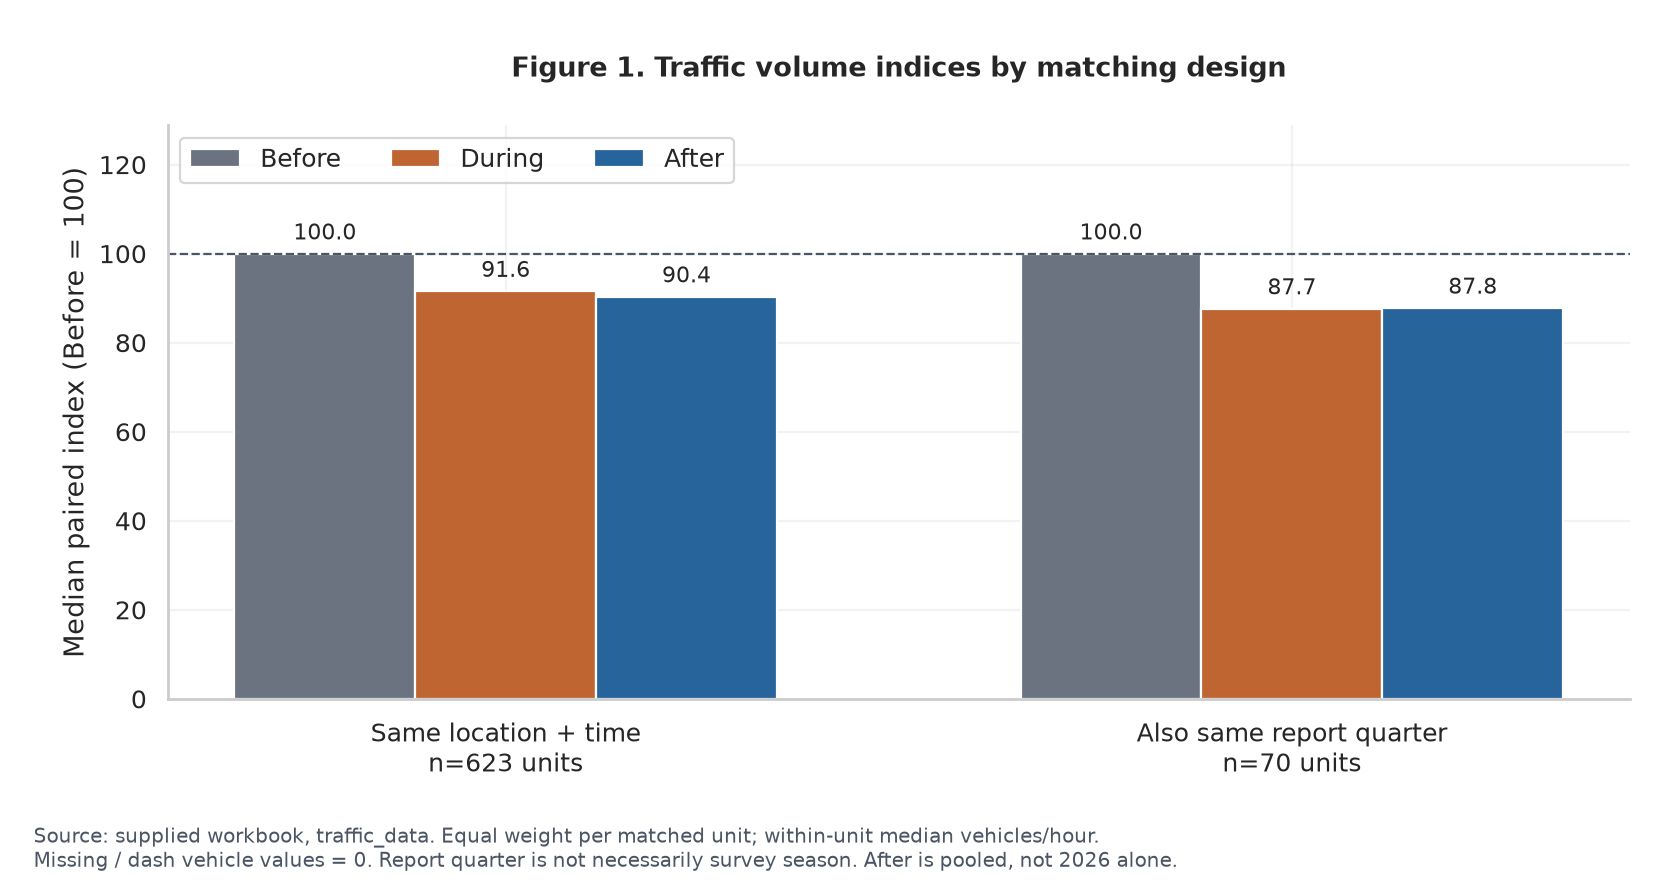

In [8]:
display(Image(filename=str(OUT / 'figures' / '01_matching_sensitivity.png'), width=950))

## Figure 2 — 02_time_window_vph.png

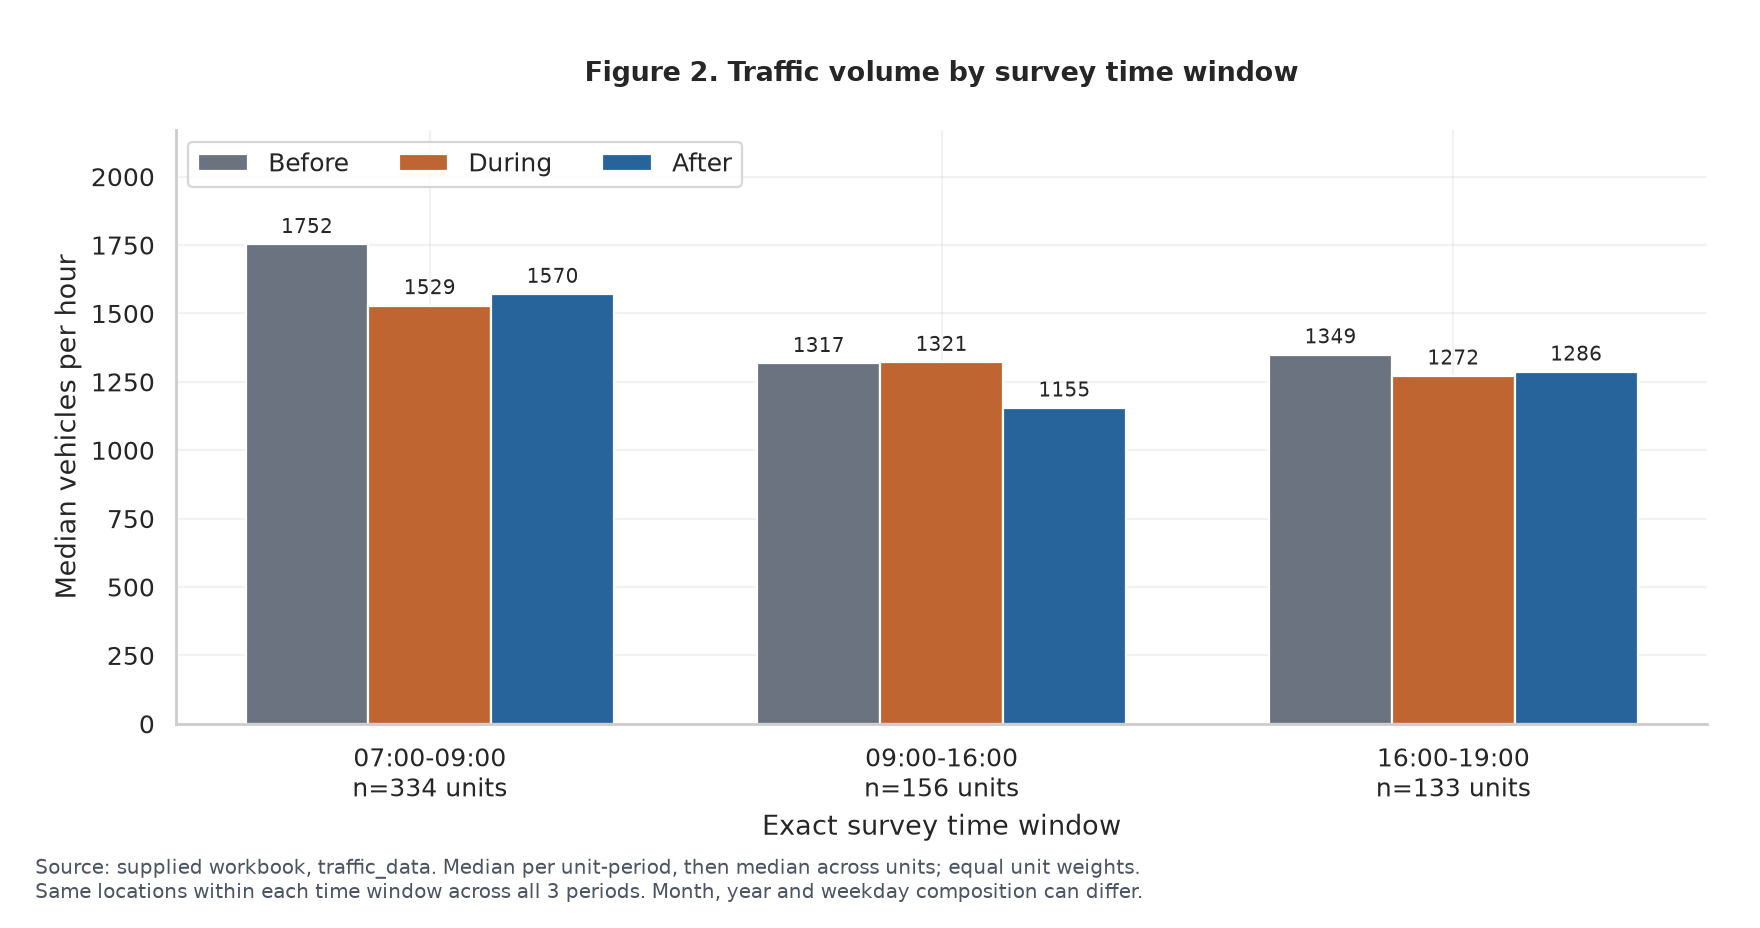

In [9]:
display(Image(filename=str(OUT / 'figures' / '02_time_window_vph.png'), width=950))

## Figure 3 — 03_paired_scatter.png

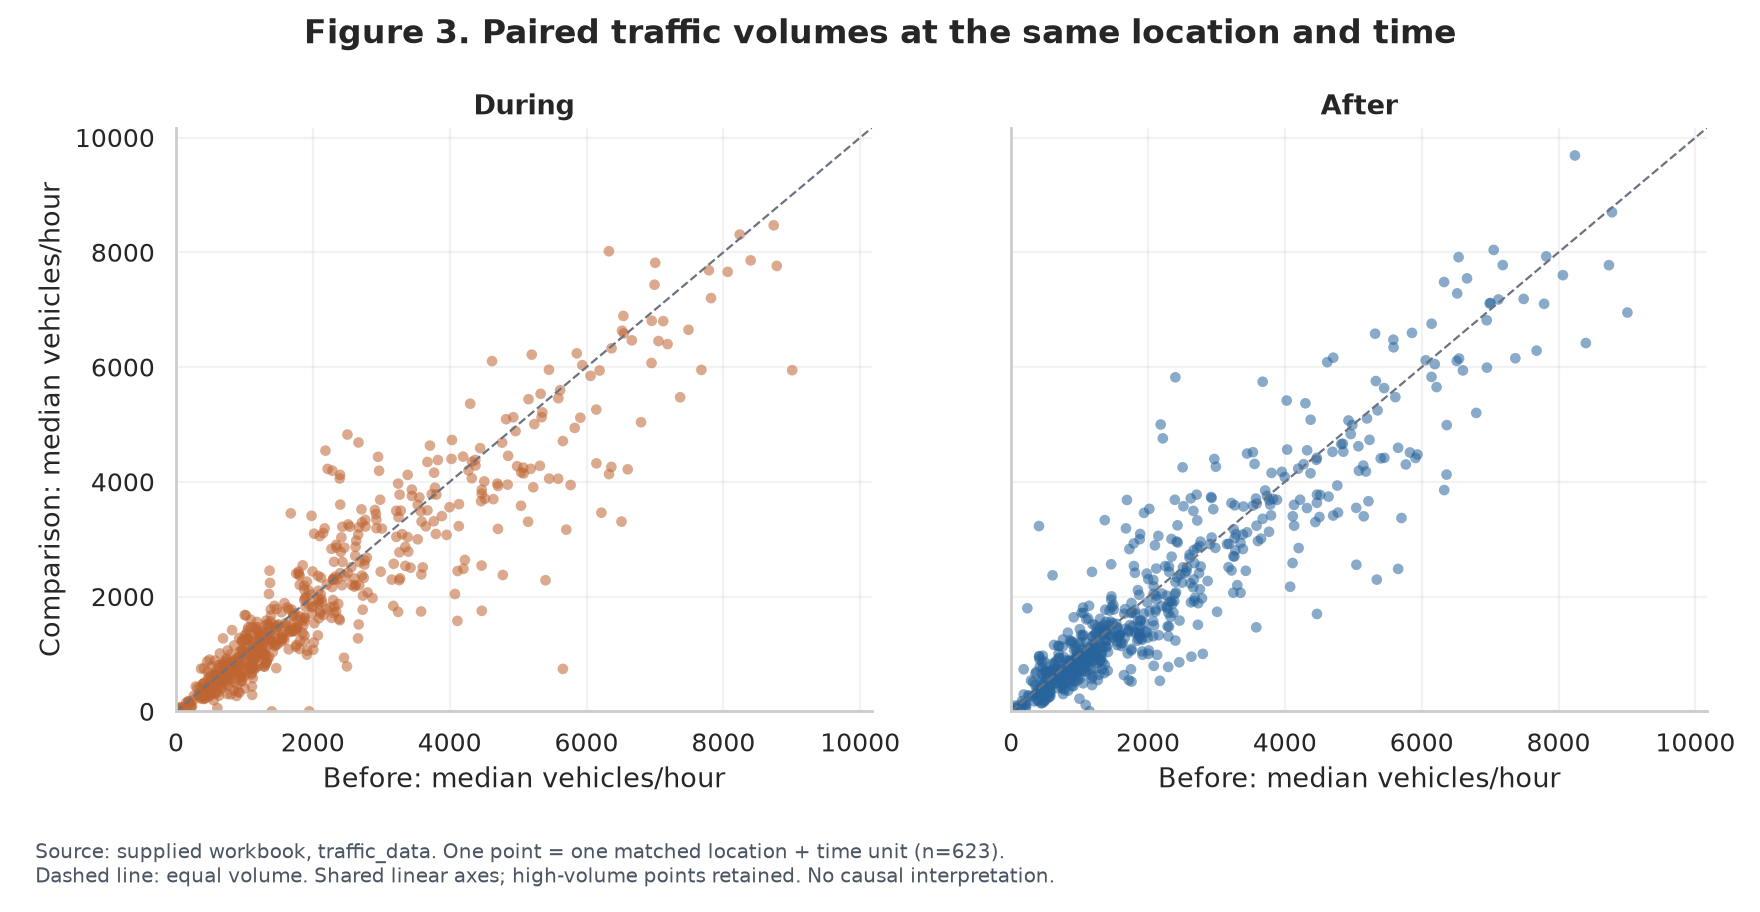

In [10]:
display(Image(filename=str(OUT / 'figures' / '03_paired_scatter.png'), width=950))

## Figure 4 — 04_vehicle_mix.png

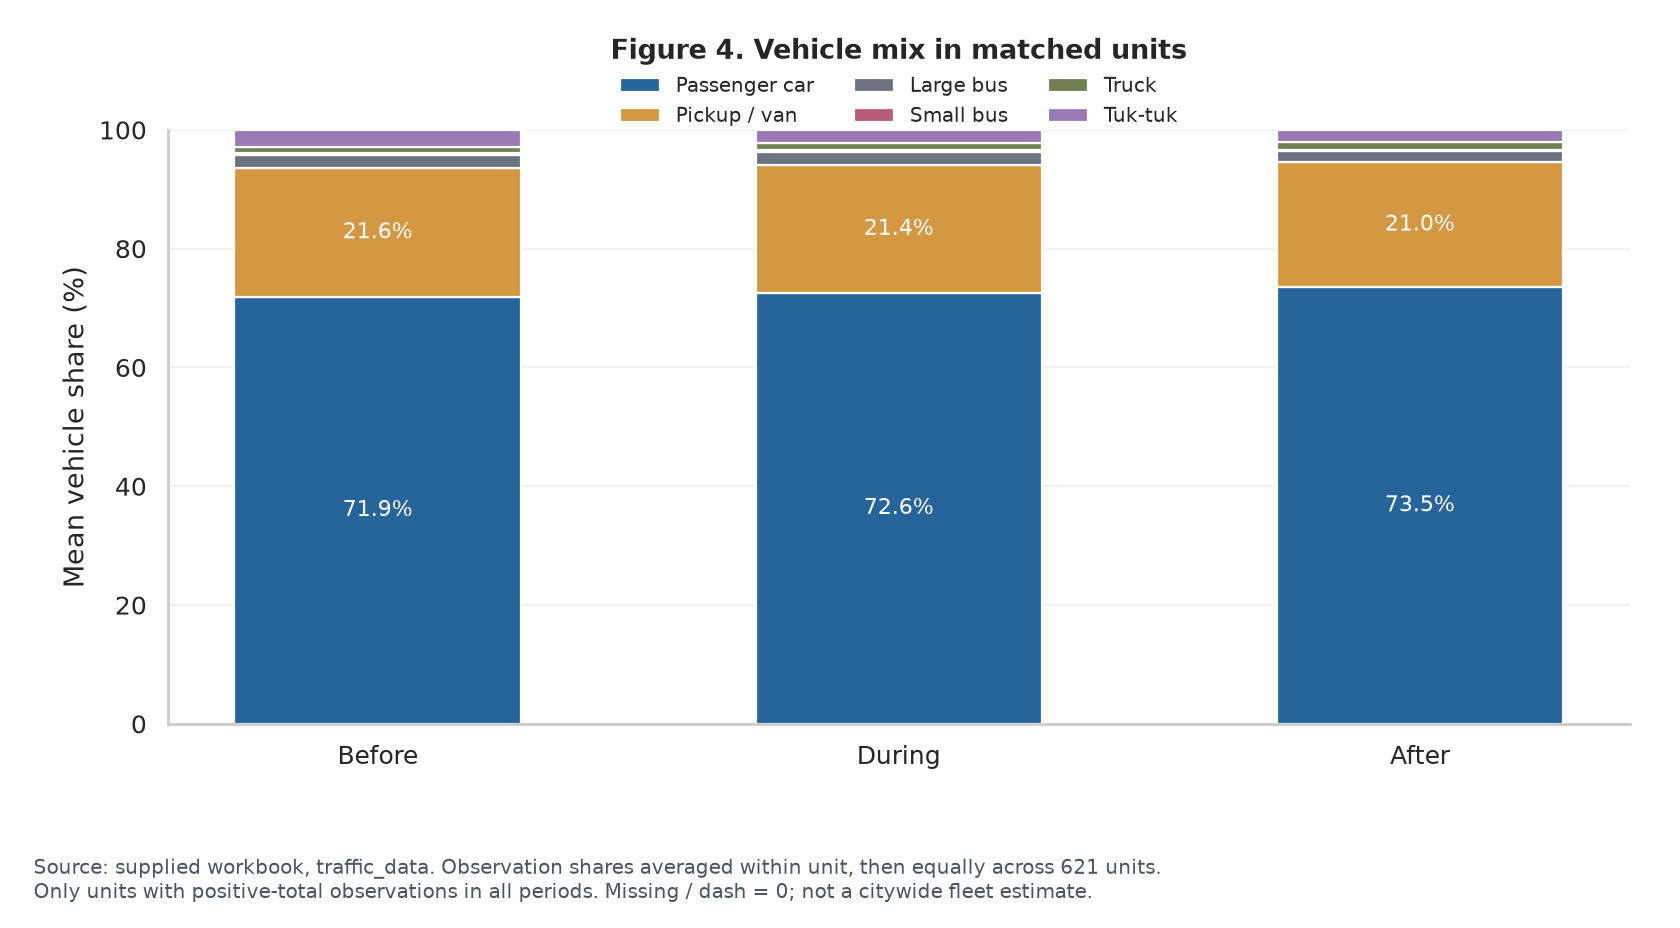

In [11]:
display(Image(filename=str(OUT / 'figures' / '04_vehicle_mix.png'), width=950))

## Figure 5 — Coverage ของข้อมูลตามปีและเดือนรายงาน

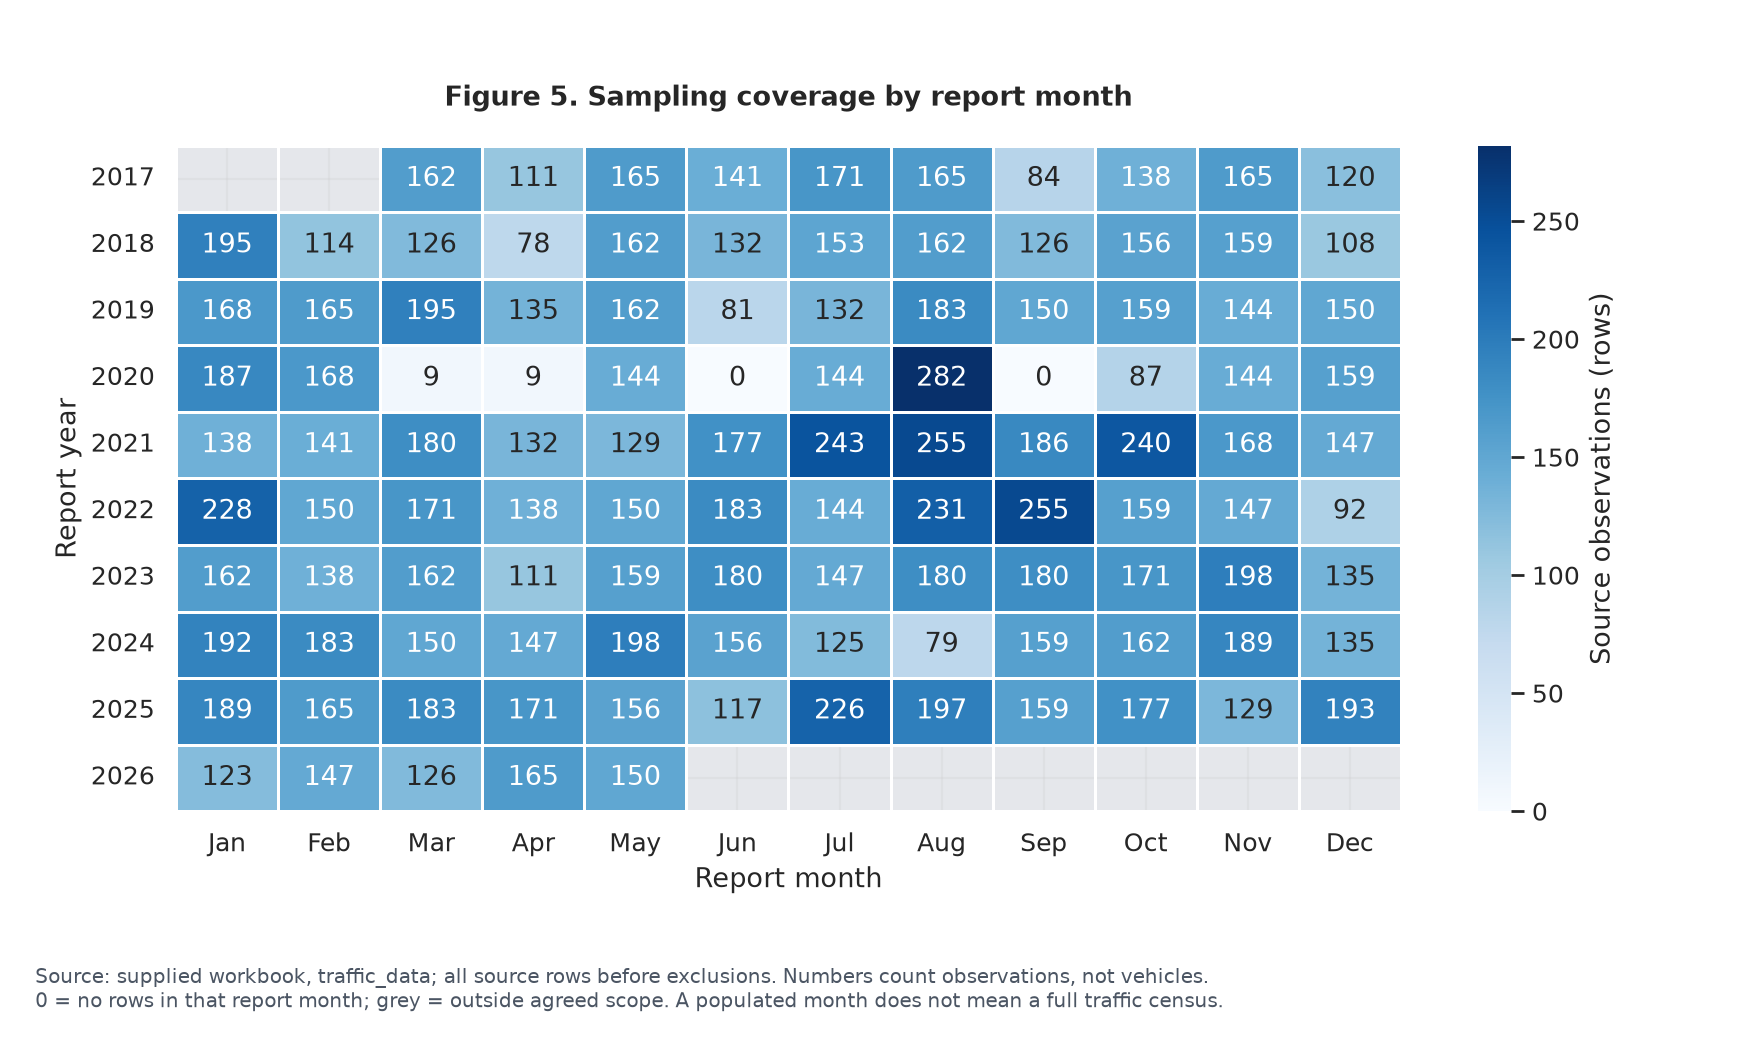

In [12]:
display(Image(filename=str(OUT / 'figures' / '05_report_coverage.png'), width=950))

## Figure 6 — การกระจายดัชนีปริมาณรถใน matched units

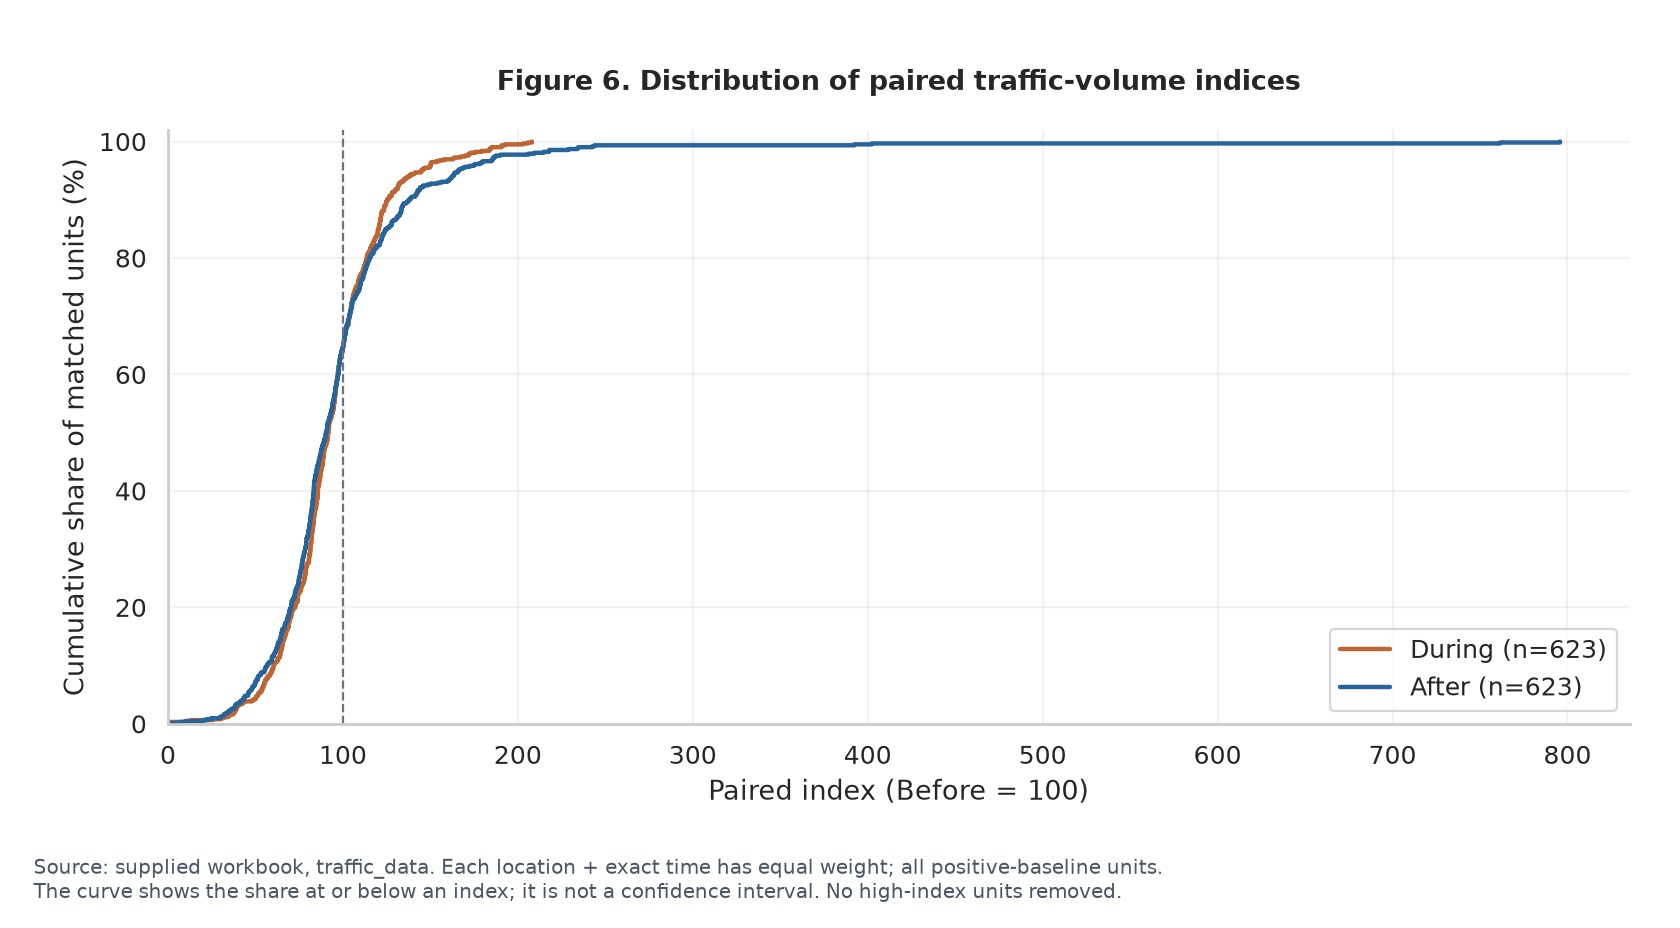

In [13]:
display(Image(filename=str(OUT / 'figures' / '06_recovery_distribution.png'), width=950))

## Figure 7 — เช้าและเย็นบนสถานที่และวันสำรวจชุดเดียวกัน

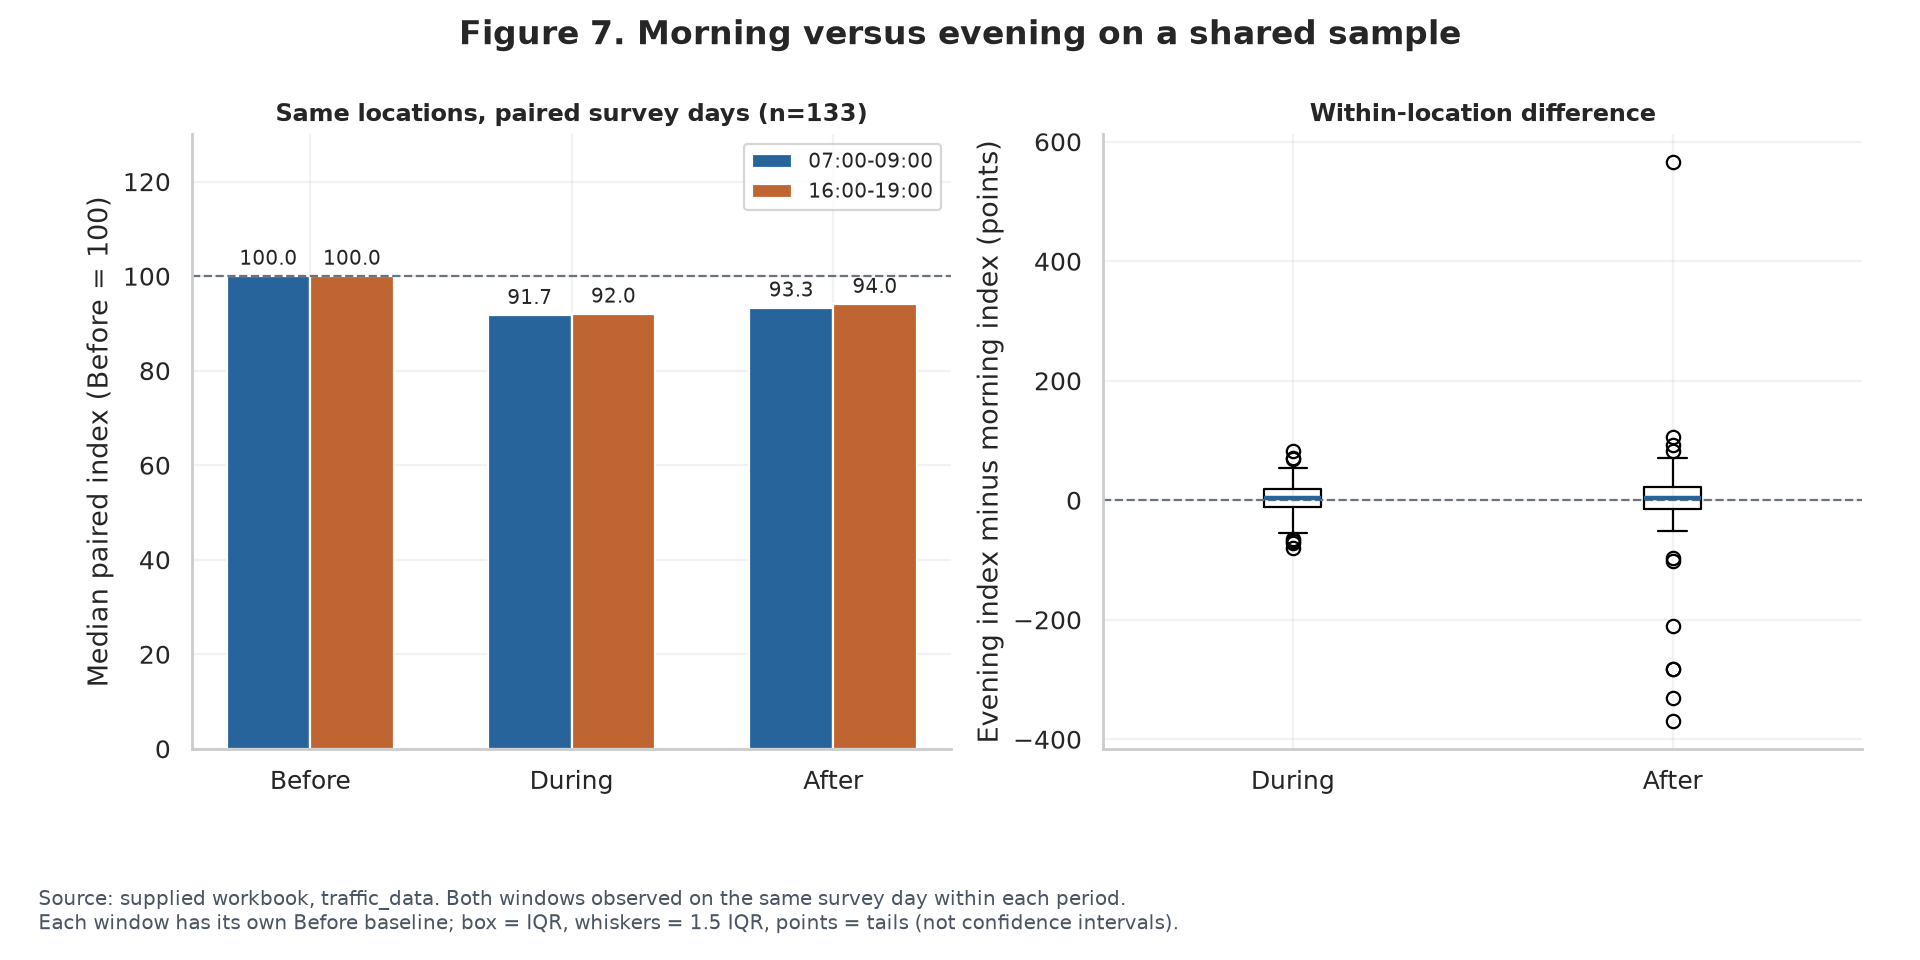

In [14]:
display(Image(filename=str(OUT / 'figures' / '07_paired_morning_evening.png'), width=950))

## Figure 8 — ตัวอย่างสถานที่ช่วงเช้าที่ควรติดตาม

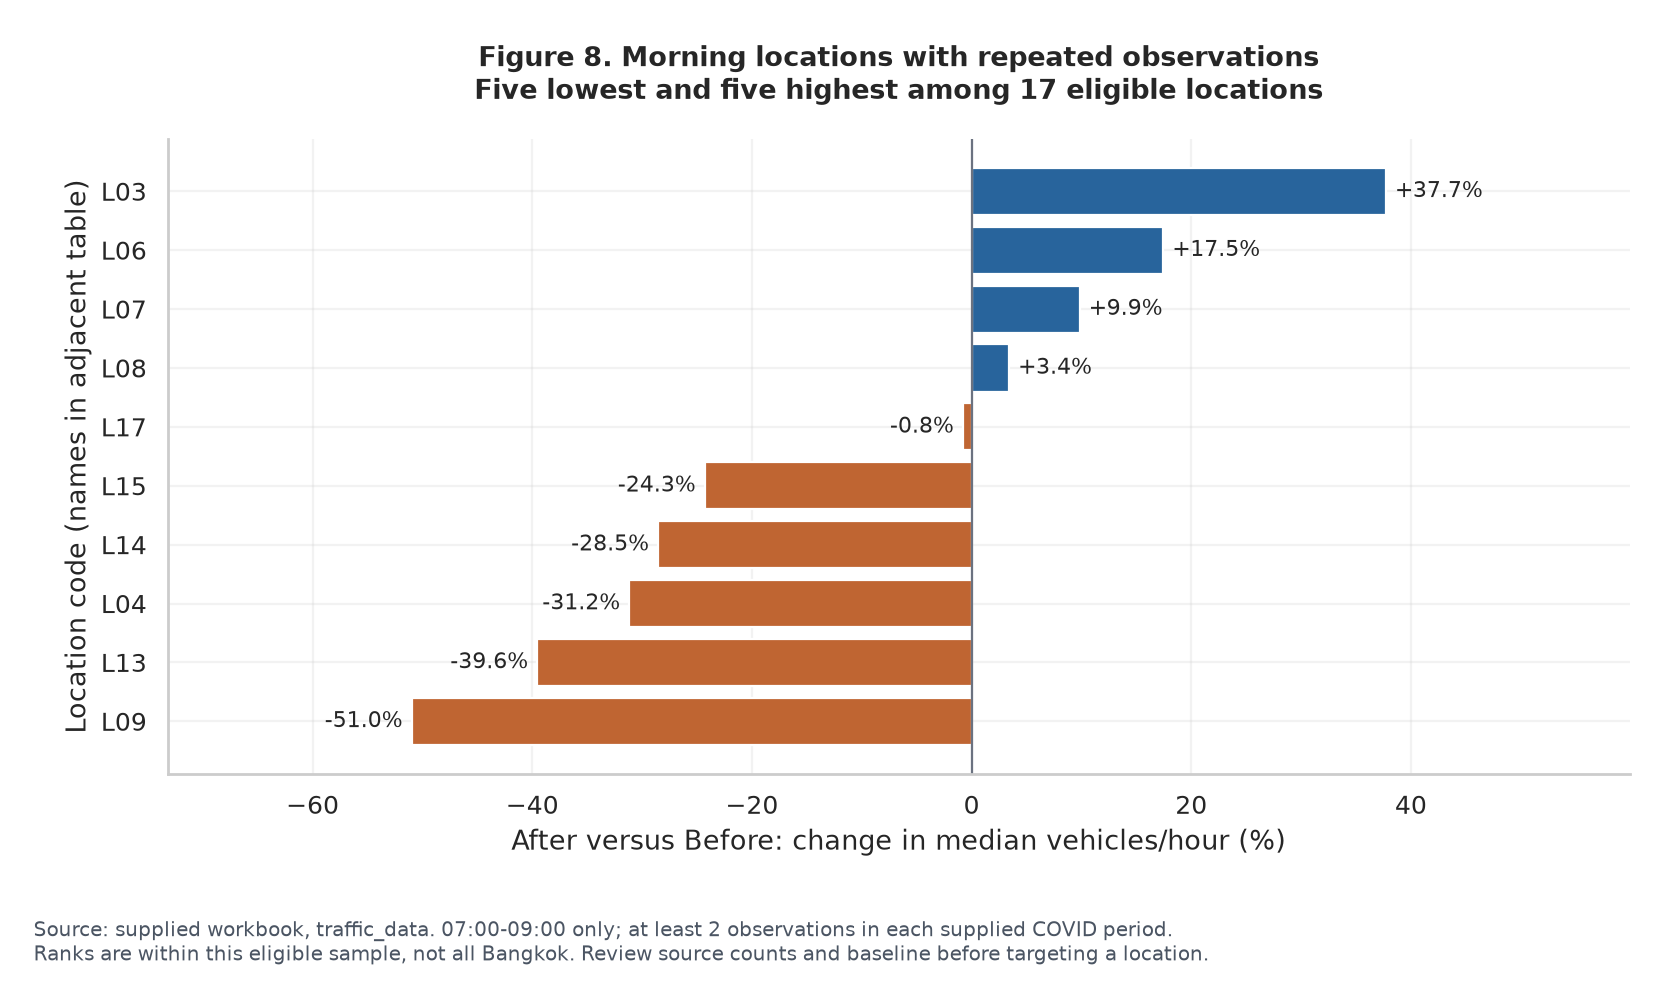

In [15]:
display(Image(filename=str(OUT / 'figures' / '08_morning_location_ranking.png'), width=950))

In [16]:
display(pd.read_csv(OUT/'morning_location_ranking_displayed.csv').round(2))

,intersection_key,road_key,Before,During,After,after_change_pct,location_code,n_Before,n_During,n_After
0,มิตรไมตรี - มิตรไมตรี 2,มิตรไมตรี,1360.75,946.50,667.00,-50.98,L09,2,3,3
1,หลักสี่,กำแพงเพชร 6,1756.00,1391.00,1061.50,-39.55,L13,2,2,3
2,บางยี่เรือ,เทอดไท,733.00,887.00,504.50,-31.17,L04,2,2,3
3,หลักสี่,แจ้งวัฒนะ,3428.75,2503.25,2450.00,-28.55,L14,2,2,3
4,ห้วยขวาง,ประชาสงเคราะห์,641.00,1010.50,485.25,-24.30,L15,2,2,4
5,เตาปูน,ประชาราษฎร์สาย 2,1537.75,1212.00,1525.50,-0.80,L17,2,2,2
6,พระราม 9,อโศกดินแดง,2929.50,3192.25,3029.75,3.42,L08,2,2,2
7,พระราม 9,รัชดาภิเษก,3268.50,3777.25,3590.50,9.85,L07,2,2,2
8,พระราม 9,พระราม 9,2119.25,2331.50,2489.25,17.46,L06,2,2,2
9,บางขุนนนท์,จรัญสนิทวงศ์,2100.50,3054.00,2893.00,37.73,L03,2,2,3


## Figure 9 — การเปลี่ยนสัดส่วนรถเป็น percentage points

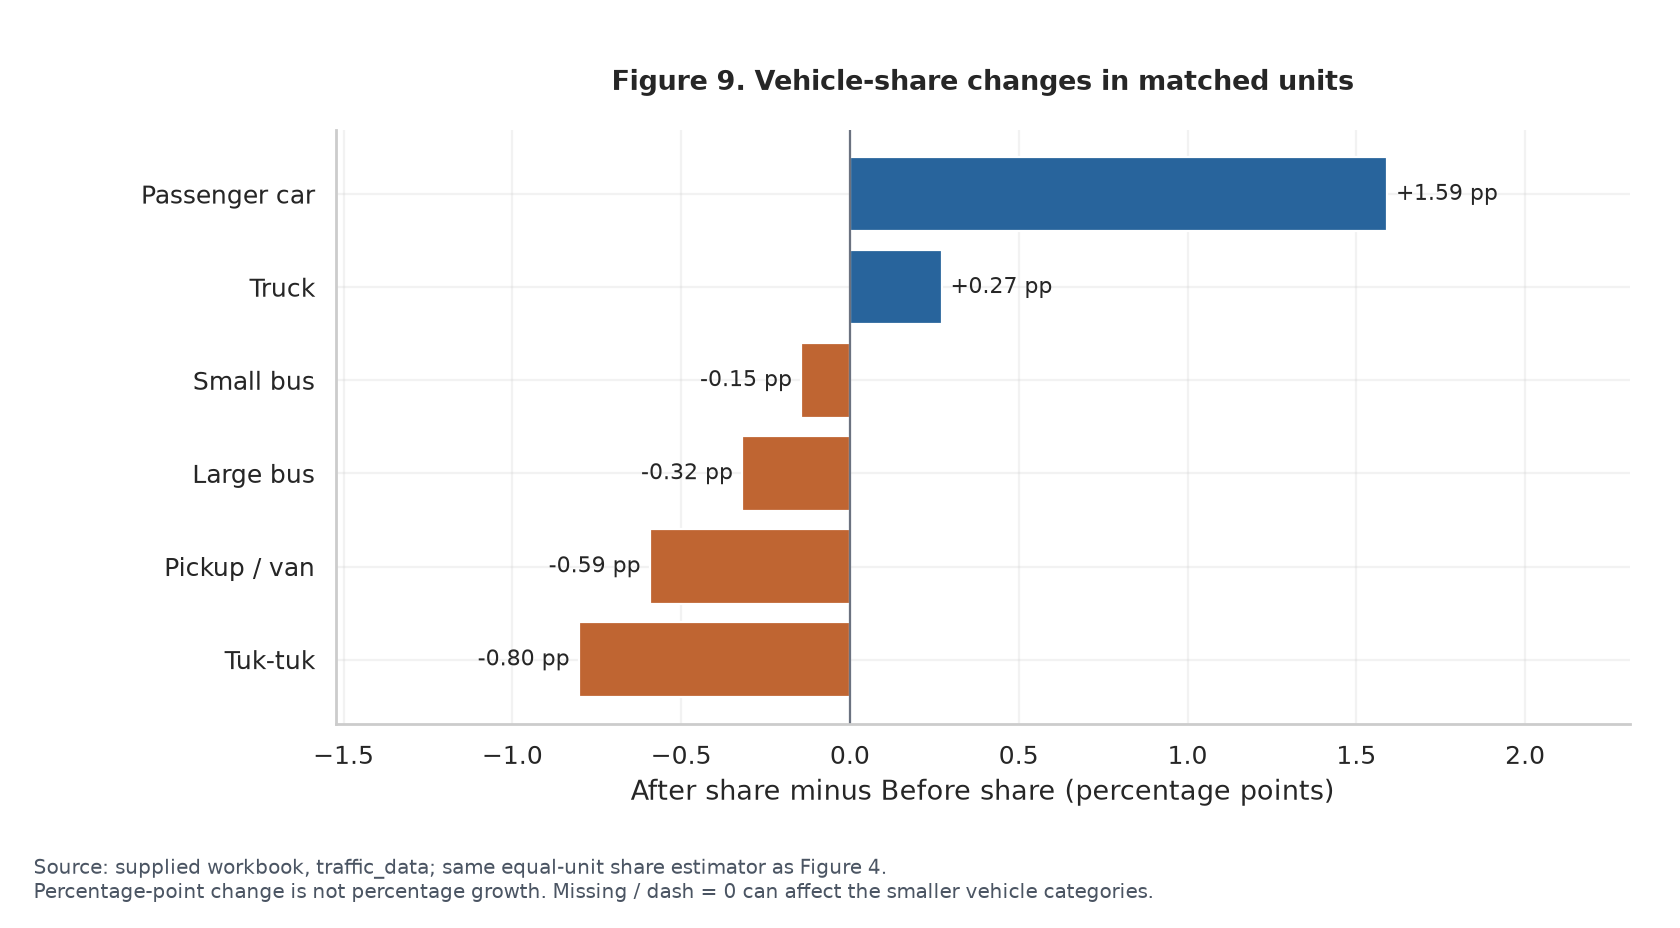

In [17]:
display(Image(filename=str(OUT / 'figures' / '09_vehicle_share_change.png'), width=950))

## Figure 10 — ปี 2026 เทียบ Before เฉพาะเดือนตรงกัน

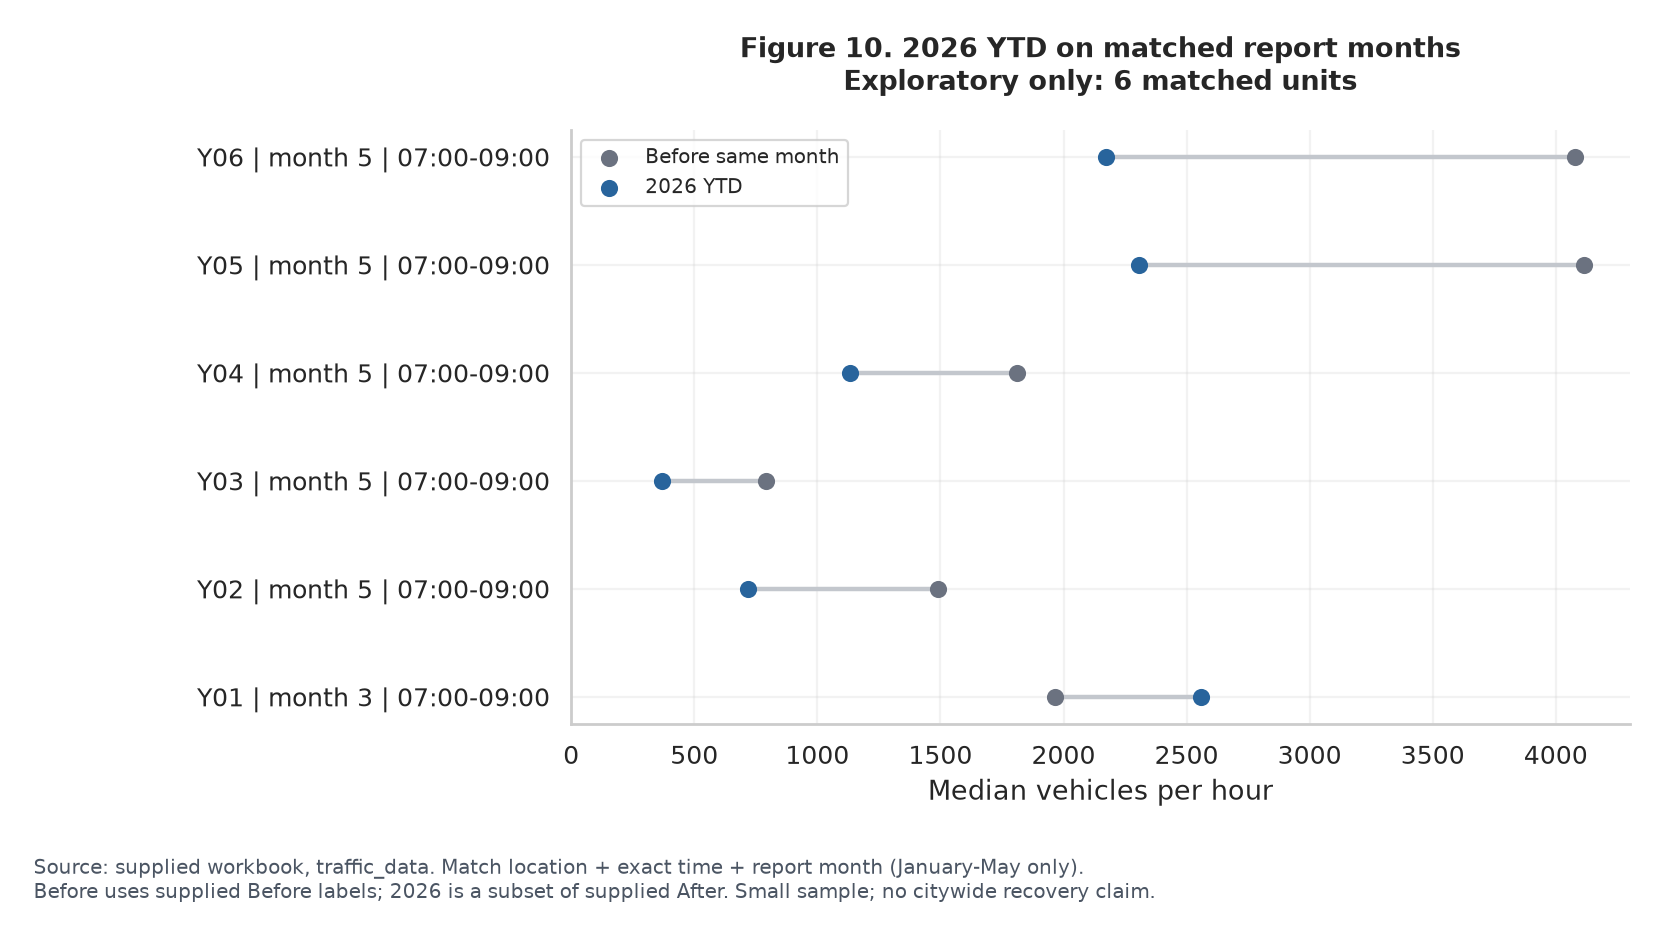

In [18]:
display(Image(filename=str(OUT / 'figures' / '10_2026_matched_months.png'), width=950))

In [19]:
display(pd.read_csv(OUT/'year2026_matched_month_units.csv').round(2))

,intersection_key,road_key,time_key,report_month,Before,2026 YTD,paired_index,unit_code
0,บางขุนนนท์,จรัญสนิทวงศ์,07:00-09:00,3,1967.0,2560.5,130.17,Y01
1,บางยี่เรือ,อินทรพิทักษ์,07:00-09:00,5,1489.5,717.5,48.17,Y02
2,บางยี่เรือ,เทอดไท,07:00-09:00,5,792.5,368.5,46.50,Y03
3,บางยี่เรือ,เพชรเกษม,07:00-09:00,5,1813.0,1131.0,62.38,Y04
4,อุรุพงษ์,พระรามที่ 6,07:00-09:00,5,4112.5,2305.5,56.06,Y05
5,อุรุพงษ์,เพชรบุรี,07:00-09:00,5,4077.5,2172.0,53.27,Y06


## สมมติฐานและการเลือกกราฟสำหรับ Pitch
H1: ระดับ During ต่ำกว่า Before ใน matched sample; H2: ทิศทาง After เทียบ During เปลี่ยนตามการ matching; H3: มีการจับคู่เช้า–เย็นบนสถานที่และวันเดียวกันแล้ว ดูรูป 7; H4: การเปลี่ยนแปลงกระจายไม่เท่ากัน ดูรูป 6/8; H5: สัดส่วนรถเปลี่ยน ดูรูป 4/9 แต่ขึ้นกับสมมติฐาน 0

สำหรับ Pitch แนะนำภาพรวม → coverage → ผลหลัก → เช้า/เย็น → ตัวอย่างสถานที่ → ข้อเสนอแนะ ไม่จำเป็นต้องแสดงทุกกราฟ งานรุ่นพี่ที่ใช้ศึกษาโครงเรื่อง: https://github.com/techasit239/Dads-5001-Accident-Is-You-Dont-Love ไม่ได้นำโค้ดหรือข้อมูลอุบัติเหตุมาใช้

## ตรวจผลและข้อจำกัด
After รวมหลายปี ไม่ใช่ผลเฉพาะปี 2026; กลุ่มไตรมาสรายงานไม่รับรองฤดูกาลสำรวจตรงกัน; ค่า 0 ที่แทนเป็นสมมติฐานผู้ใช้ ไม่สรุปเหตุและผลจาก COVID หรือใช้จำนวนรถแทนความเร็ว/รถติด

In [20]:
analysis = pd.read_csv(ROOT / 'data/processed/traffic_matched_analysis.csv', low_memory=False)
assert set(analysis.source_sha256) == {summary['source_sha256']}
assert np.allclose(analysis.vehicle_total, analysis[[c+'_clean' for c in VEHICLES]].sum(axis=1))
assert np.allclose(analysis.vehicles_per_hour * analysis.period_hours, analysis.vehicle_total)
print('Checks passed. Original Excel unchanged.')

Checks passed. Original Excel unchanged.


## ดาวน์โหลดผลลัพธ์
ZIP รวมรายงาน ตาราง กราฟ และข้อมูลที่ประมวลผล ไม่รวม Excel ต้นฉบับ บน Colab คลิกไฟล์ในแถบ Files เพื่อดาวน์โหลด

In [21]:
from zipfile import ZipFile, ZIP_DEFLATED
archive = ROOT.parent / 'bangkok_traffic_results.zip'
with ZipFile(archive, 'w', ZIP_DEFLATED) as z:
    for folder in [ROOT / 'outputs', ROOT / 'data/processed']:
        for path in folder.rglob('*'):
            if path.is_file():
                z.write(path, path.relative_to(ROOT))
print('Results ZIP:', archive.name)
if IN_COLAB:
    print('เปิดแถบ Files ทางซ้าย แล้วดาวน์โหลด bangkok_traffic_results.zip')

Results ZIP: bangkok_traffic_results.zip
